# Nshift assignment analysis

Notebook solver-log style per output `tests/Nshift_speed/output/N*`.
Permette selezione `first_per_slot` / `last_per_slot` e usa la stessa funzione di plot di `solver_logs_analysis`.

In [17]:
%matplotlib inline
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

plt.rcParams['figure.dpi'] = 68

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

# --- user options ---
SELECTED_N = 4
RUN_SELECTION_MODE = "first_per_slot"  # all | first_per_slot | last_per_slot | all_for_slot
TARGET_SLOT = None  # used only with all_for_slot

# Final timeline highlight plot mode:
# - "scatter": current scatter timeline only
# - "stacked": stacked bar timeline only
# - "both": scatter + stacked
TIMELINE_HIGHLIGHT_PLOT_MODE = "both"
TIMELINE_HIGHLIGHT_DARK_FACTOR = 0.55


In [18]:
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
online2_dir = next((p for p in candidates if (p / "tests" / "Nshift_speed").exists()), None)
if online2_dir is None:
    raise FileNotFoundError("Cannot locate online2 root (missing tests/Nshift_speed).")

if str(online2_dir) not in sys.path:
    sys.path.insert(0, str(online2_dir))

notebooks_dir = online2_dir / "notebooks"
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

import nb_utils
importlib.reload(nb_utils)
from nb_utils import (
    FLAVOUR_COLORS,
    make_prehistory_by_slot,
    compute_decay_window_avg,
    bool_series as _bool_series,
    resolve_plot_mode as _resolve_plot_mode,
    prepare_local as _prepare_local,
    prepare_local as _prepare_timeline,
    flavour_order as _flavour_order,
)

import importlib
import visualize_solver_logs as viz
importlib.reload(viz)
from visualize_solver_logs import select_run_ids, plot_solver_execution_stacked
nshift_dir = online2_dir / "tests" / "Nshift_speed"
cfg = json.loads((nshift_dir / "config.json").read_text(encoding="utf-8"))
scenario_path = nshift_dir / str(cfg["scenario_path"])
scenario = json.loads(scenario_path.read_text(encoding="utf-8"))
if not scenario.get("metadata", {}).get("prehistory_enabled", True):
    scenario = dict(scenario)
    scenario["prehistory_slots"] = []

output_dir = nshift_dir / "output"
run_dir = output_dir / f"N{int(SELECTED_N)}"
if not run_dir.exists():
    raise FileNotFoundError(f"Missing output folder for N={SELECTED_N}: {run_dir}")

summary_df = pd.read_csv(output_dir / "summary_by_n.csv")
summary_df["batch_size"] = pd.to_numeric(summary_df["batch_size"], errors="coerce")
run_summary = summary_df[summary_df["batch_size"] == int(SELECTED_N)]
if run_summary.empty:
    raise ValueError(f"N={SELECTED_N} not found in summary_by_n.csv")

per_request = pd.read_csv(run_dir / "per_request.csv")
batch_timings = pd.read_csv(run_dir / "batch_timings.csv")

# Extract scenario parameters directly from metadata (single source of truth).
meta = scenario["metadata"]
total_slots = int(meta["total_slots"])
error_window_past = int(meta["error_window_past"])
error_window_future = int(meta["error_window_future"])
error_window_past_decay_slots = int(meta.get("error_window_past_decay_slots", 0))
max_error_threshold = float(meta["max_error_threshold"])

batch_seq_col = "batch_sequence" if "batch_sequence" in per_request.columns else "included_in_batch_sequence"
if batch_seq_col not in per_request.columns:
    raise KeyError("Missing batch sequence column in per_request.csv")

slot_col = "current_slot" if "current_slot" in batch_timings.columns else "slot"
if slot_col not in batch_timings.columns:
    raise KeyError("Missing slot/current_slot column in batch_timings.csv")

base_cols = ["request_id", "scheduled_slot", "flavour_name", "deadline_slot", "error", "carbon_cost", batch_seq_col]
missing = [c for c in base_cols if c not in per_request.columns]
if missing:
    raise KeyError(f"Missing required per_request columns: {missing}")

req_df = per_request[base_cols].copy()
req_df["request_id"] = pd.to_numeric(req_df["request_id"], errors="coerce")
req_df["scheduled_slot"] = pd.to_numeric(req_df["scheduled_slot"], errors="coerce")
req_df["deadline_slot"] = pd.to_numeric(req_df["deadline_slot"], errors="coerce")
req_df["error"] = pd.to_numeric(req_df["error"], errors="coerce")
req_df["carbon_cost"] = pd.to_numeric(req_df["carbon_cost"], errors="coerce")
req_df[batch_seq_col] = pd.to_numeric(req_df[batch_seq_col], errors="coerce")
req_df = req_df.dropna(subset=["request_id", "scheduled_slot", batch_seq_col])
req_df["request_id"] = req_df["request_id"].astype(int)
req_df["scheduled_slot"] = req_df["scheduled_slot"].astype(int)
req_df[batch_seq_col] = req_df[batch_seq_col].astype(int)

timings_df = batch_timings.copy()
timings_df["batch_sequence"] = pd.to_numeric(timings_df["batch_sequence"], errors="coerce")
timings_df[slot_col] = pd.to_numeric(timings_df[slot_col], errors="coerce")
timings_df["solver_elapsed_ms"] = pd.to_numeric(timings_df["solver_elapsed_ms"], errors="coerce")
timings_df = timings_df.dropna(subset=["batch_sequence", slot_col, "solver_elapsed_ms"])
timings_df["batch_sequence"] = timings_df["batch_sequence"].astype(int)
timings_df[slot_col] = timings_df[slot_col].astype(int)

prehistory_by_slot = make_prehistory_by_slot(scenario)
decay_slots = error_window_past_decay_slots

run_rows = []
assignment_rows = []

# Build a synthetic runs_df compatible with visualize_solver_logs:
# one row per solver execution, with cumulative state up to that run.
for row in timings_df.sort_values("batch_sequence").itertuples(index=False):
    run_seq = int(row.batch_sequence)
    current_slot = int(getattr(row, slot_col))
    elapsed_ms = float(getattr(row, "solver_elapsed_ms"))

    # Cumulative state after this run: include all assignments with
    # batch_sequence <= current run sequence.
    state_df = req_df[(req_df[batch_seq_col] <= run_seq) & (req_df["scheduled_slot"] >= 0)].copy()
    state_df["is_new_assignment_in_run"] = state_df[batch_seq_col] == run_seq

    new_df = req_df[req_df[batch_seq_col] == run_seq]
    total_carbon_cost = float(new_df["carbon_cost"].sum()) if not new_df.empty else 0.0
    carbon_cost_per_new = float(new_df["carbon_cost"].mean()) if not new_df.empty else 0.0

    window_start = max(0, current_slot - error_window_past)
    window_end = min(total_slots - 1, current_slot + error_window_future)
    avg_real, avg_modeled = compute_decay_window_avg(
        state_df, current_slot,
        error_window_past,
        error_window_future,
        total_slots,
        decay_slots,
        prehistory_by_slot,
    )

    run_rows.append(
        {
            "run_id": str(run_seq),
            "run_sequence": run_seq,
            "current_slot": current_slot,
            "solver_start_ts": float(run_seq),
            "solver_end_ts": float(run_seq) + (elapsed_ms / 1000.0),
            "solver_elapsed_ms": elapsed_ms,
            "error_window_start_slot": window_start,
            "error_window_end_slot": window_end,
            "error_window_avg_after": avg_modeled,
            "error_window_avg_after_real": avg_real,
            "error_window_threshold": max_error_threshold,
            "total_carbon_cost": total_carbon_cost,
            "carbon_cost_per_new_request": carbon_cost_per_new,
        }
    )

    assign_cols = [
        "request_id",
        "scheduled_slot",
        "flavour_name",
        "error",
        "deadline_slot",
        "is_new_assignment_in_run",
    ]
    for a in state_df[assign_cols].itertuples(index=False):
        deadline_value = float(a.deadline_slot) if pd.notna(a.deadline_slot) else float("nan")
        assignment_rows.append(
            {
                "run_id": str(run_seq),
                "request_id": int(a.request_id),
                "scheduled_slot": int(a.scheduled_slot),
                "flavour_name": str(a.flavour_name),
                "error": float(a.error),
                "deadline_slot": deadline_value,
                "is_new_assignment_in_run": bool(a.is_new_assignment_in_run),
            }
        )

runs_df = pd.DataFrame(run_rows).sort_values("run_sequence").reset_index(drop=True)
assignments_df = pd.DataFrame(assignment_rows)

display(run_summary.round(4))
display(runs_df.head(5))
display(assignments_df.head(8))

,execution_mode,batch_size,realtime_slots,realtime_speed_scale,baseline_flavour_name,baseline_flavour_duration,baseline_flavour_error,requests_total,requests_scheduled,requests_unscheduled,batches_executed,total_carbon_cost,global_average_error,global_average_error_real,global_average_error_modeled,global_average_error_real_skip_first_k,global_average_error_modeled_skip_first_k,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,solver_time_ms_min,solver_time_ms_max,solver_time_ms_avg,queue_wait_seconds_min,queue_wait_seconds_max,queue_wait_seconds_avg,final_wait_seconds_min,final_wait_seconds_max,final_wait_seconds_avg,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline,carbon_cost_saving_vs_baseline_pct
1,nshift_dp,4,False,1.0,NaN,0,0.0,4380,4380,0,1095,3.498803e+07,3.9994,3.9994,3.9994,0.0,0.0,0,0,3.8757,442.3248,80.0924,0.0,20.0,0.2374,0.0039,80.4423,24.0641,1.276387e+08,9.265068e+07,72.5882


,run_id,run_sequence,current_slot,solver_start_ts,solver_end_ts,solver_elapsed_ms,error_window_start_slot,error_window_end_slot,error_window_avg_after,error_window_avg_after_real,error_window_threshold,total_carbon_cost,carbon_cost_per_new_request
0,1,1,0,1.0,1.239436,239.435599,0,8,3.750000,3.750000,4.0,15178.44474,3794.611185
1,2,2,0,2.0,2.029642,29.642496,0,8,3.750000,3.750000,4.0,19275.77886,4818.944715
2,3,3,0,3.0,3.235218,235.217821,0,8,3.958333,3.958333,4.0,13189.99077,3297.497693
3,4,4,0,4.0,4.104651,104.650974,0,8,3.906250,3.906250,4.0,18882.67473,4720.668682
4,5,5,0,5.0,5.252333,252.332951,0,8,4.000000,4.000000,4.0,12917.27964,3229.319910


,run_id,request_id,scheduled_slot,flavour_name,error,deadline_slot,is_new_assignment_in_run
0,1,0,4,Fast,5.0,4.0,True
1,1,1,4,Fast,5.0,4.0,True
2,1,2,8,Accurate,0.0,8.0,True
3,1,3,5,Fast,5.0,6.0,True
4,2,0,4,Fast,5.0,4.0,False
5,2,1,4,Fast,5.0,4.0,False
6,2,2,8,Accurate,0.0,8.0,False
7,2,3,5,Fast,5.0,6.0,False


Selected 71 runs for N=4: ['1', '9', '33', '39', '55', '68', '89', '93'] ...


/tmp/ipykernel_204857/264292128.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_requests = assignments_df[assignments_df["run_id"].isin(selected_run_ids)].groupby("request_id").apply(lambda df: df.sort_values("scheduled_slot").iloc[-1])


142


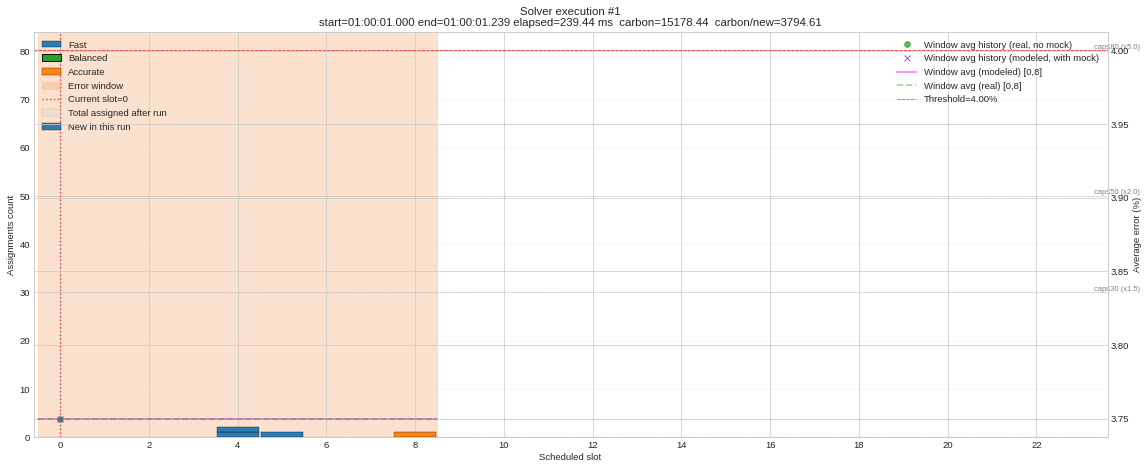

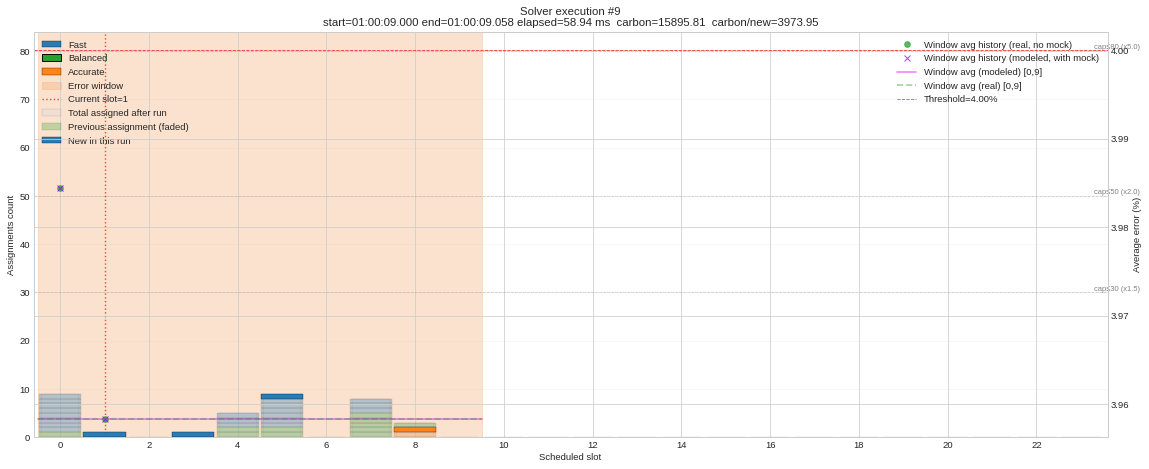

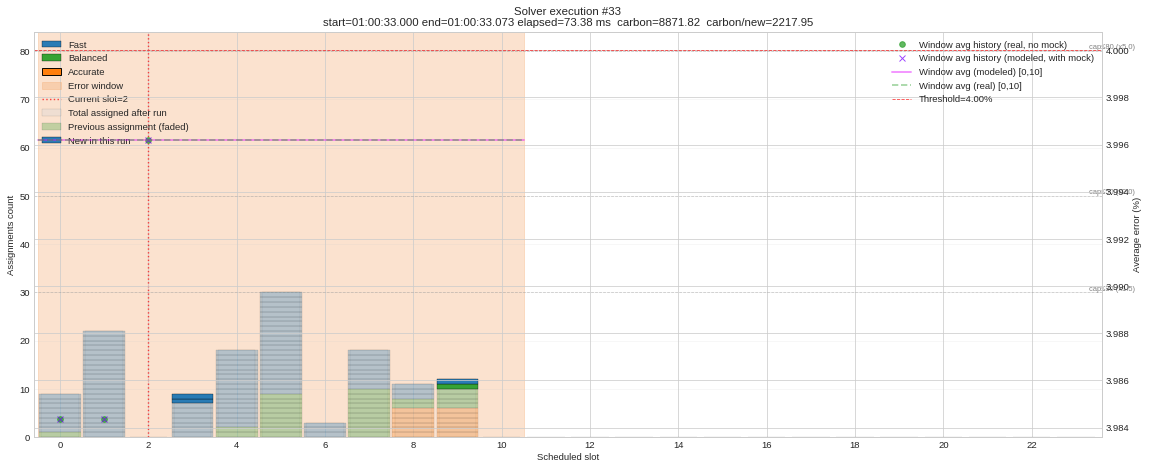

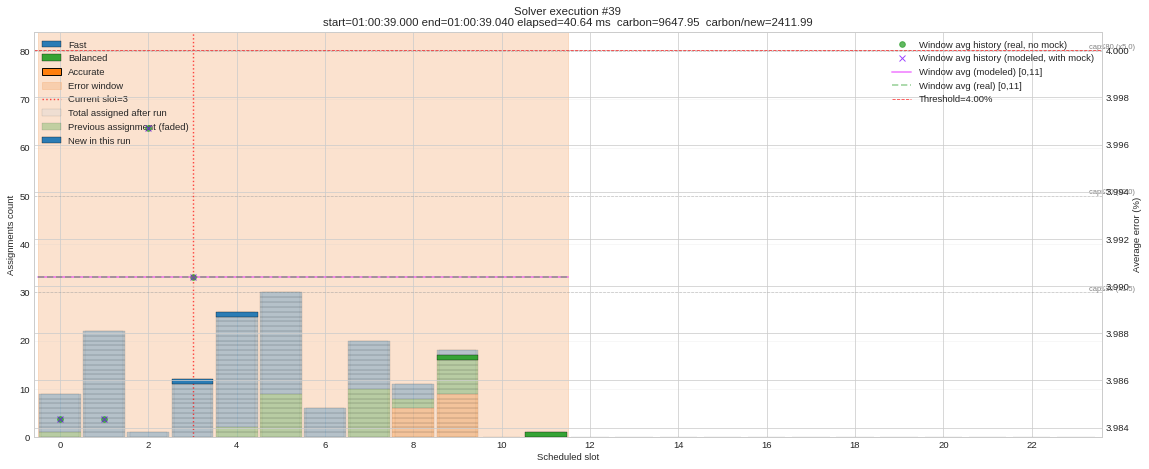

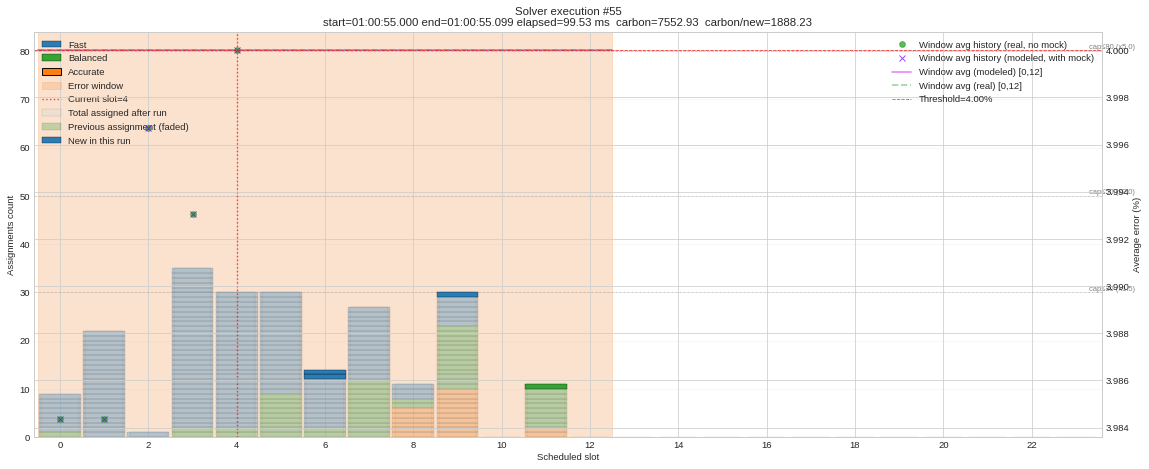

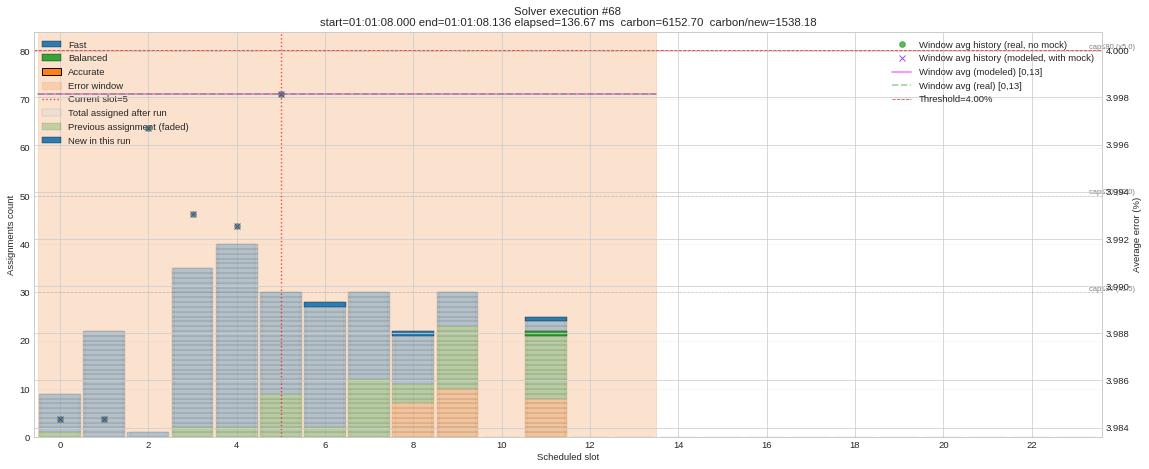

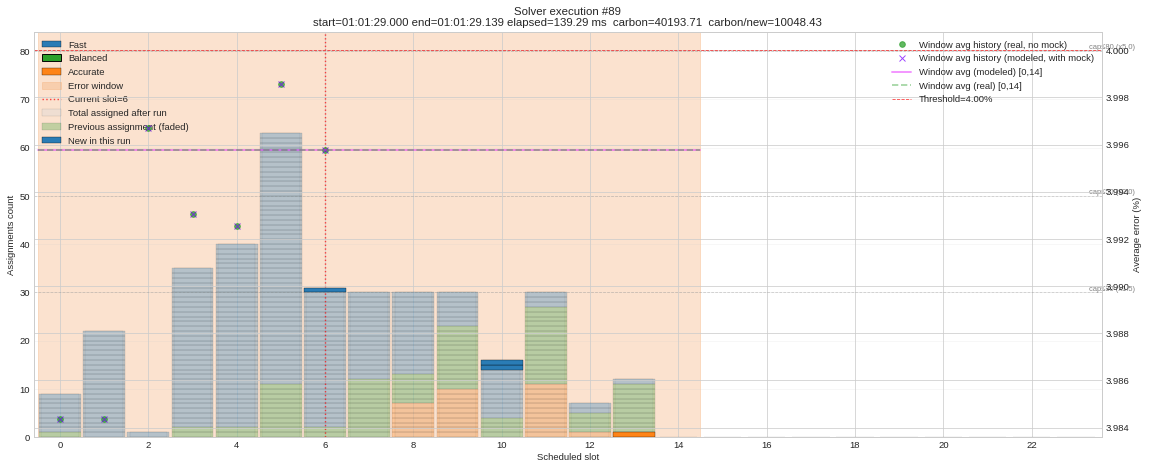

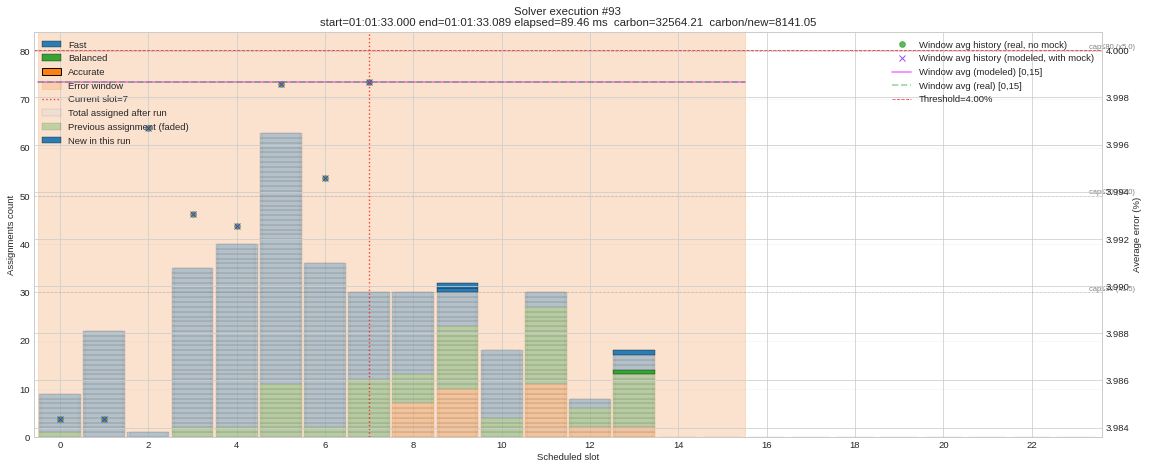

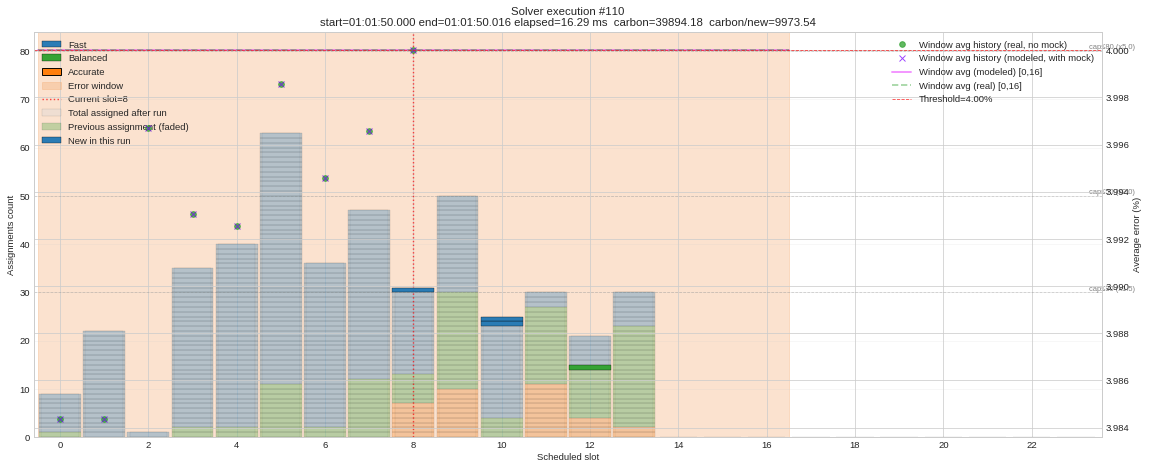

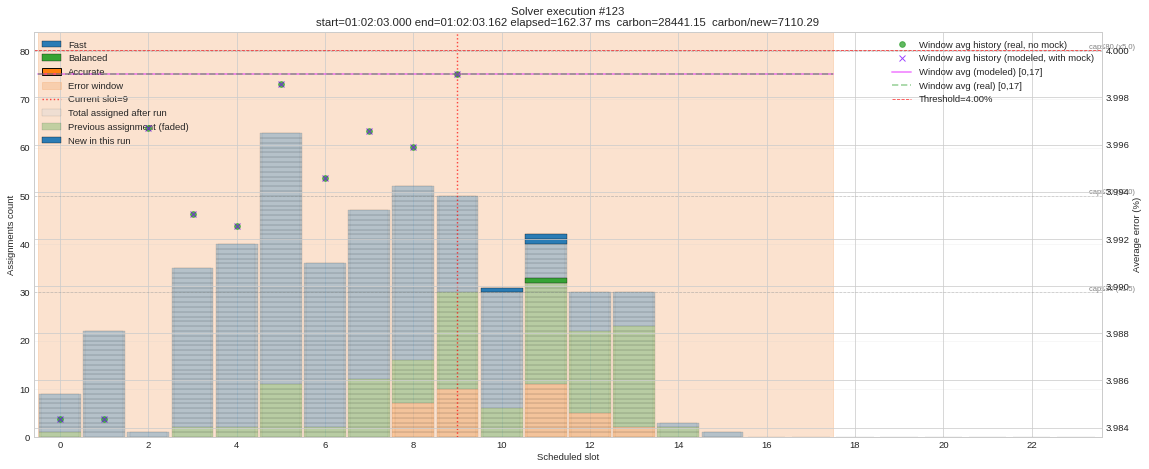

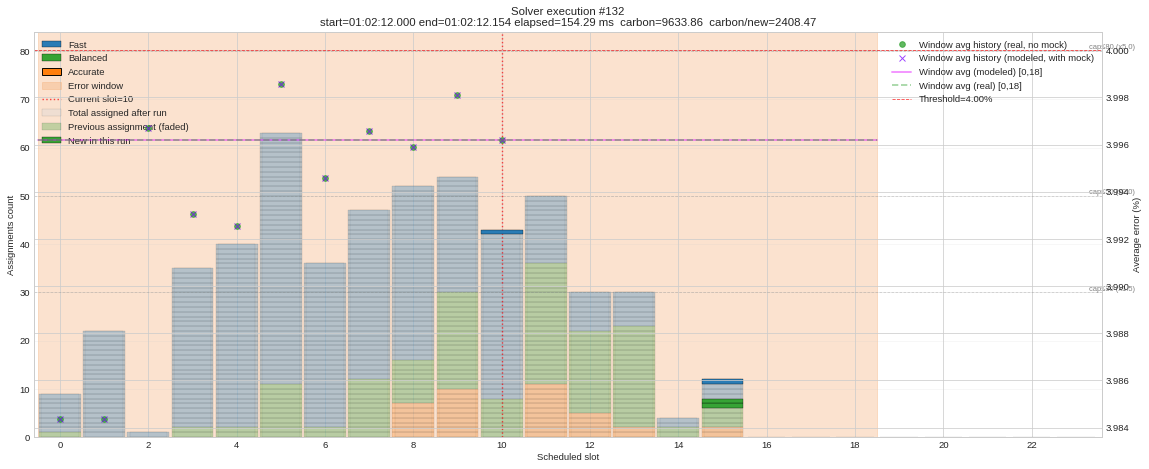

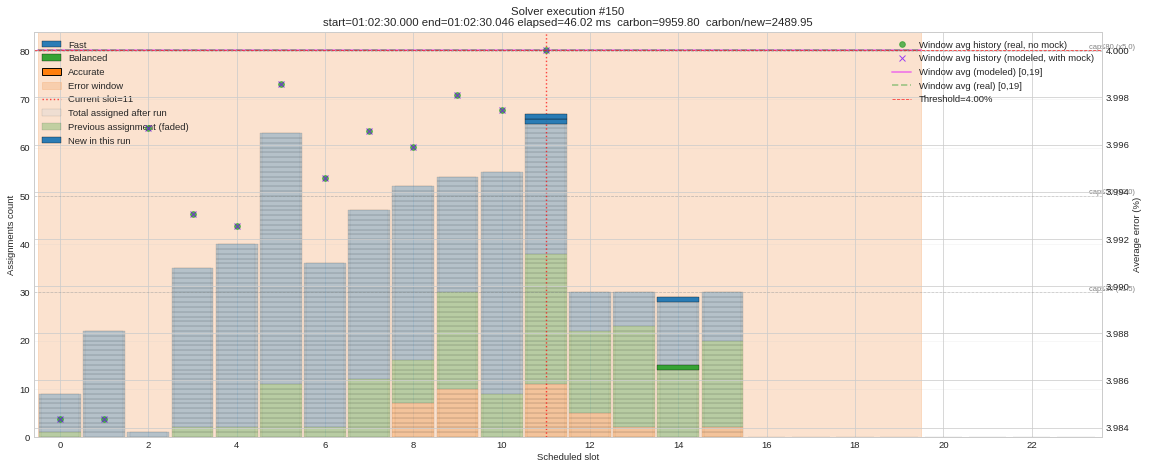

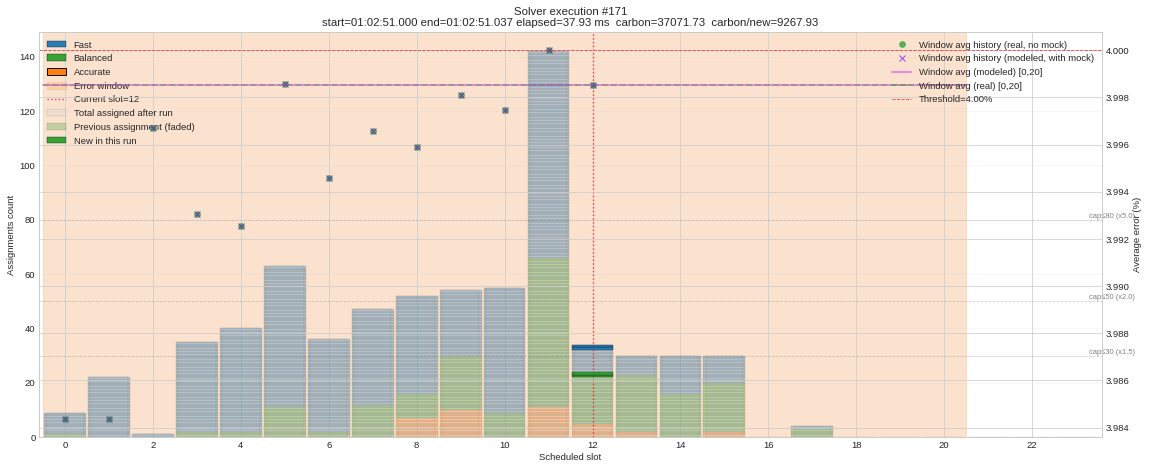

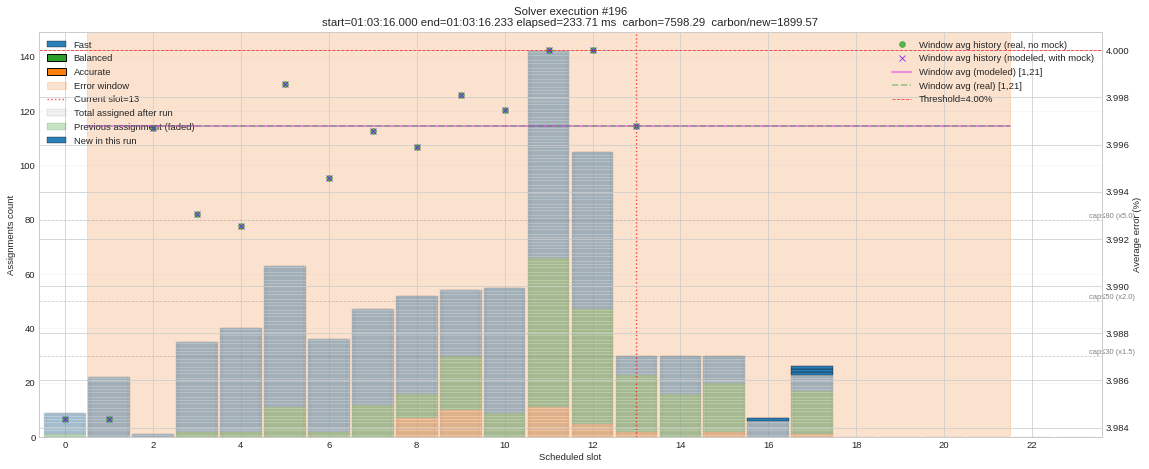

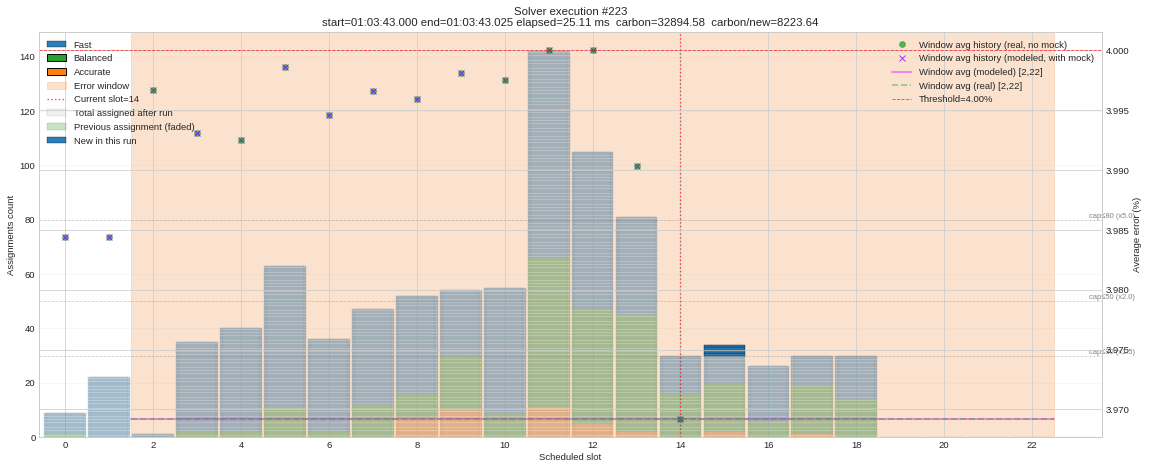

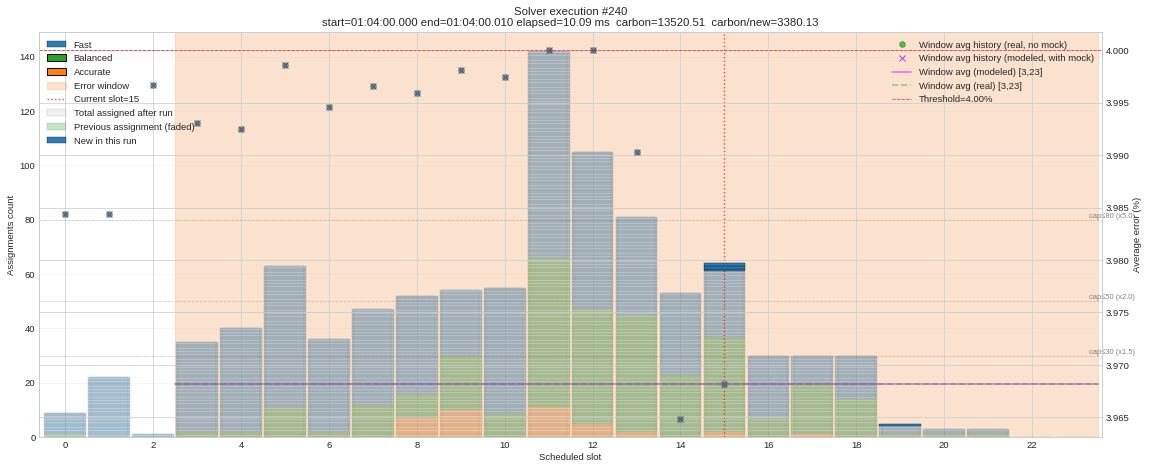

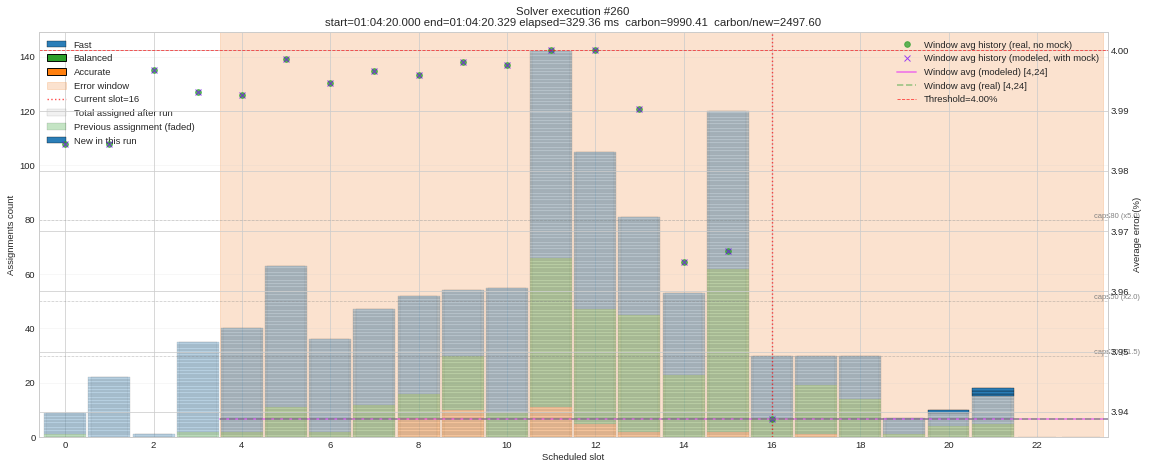

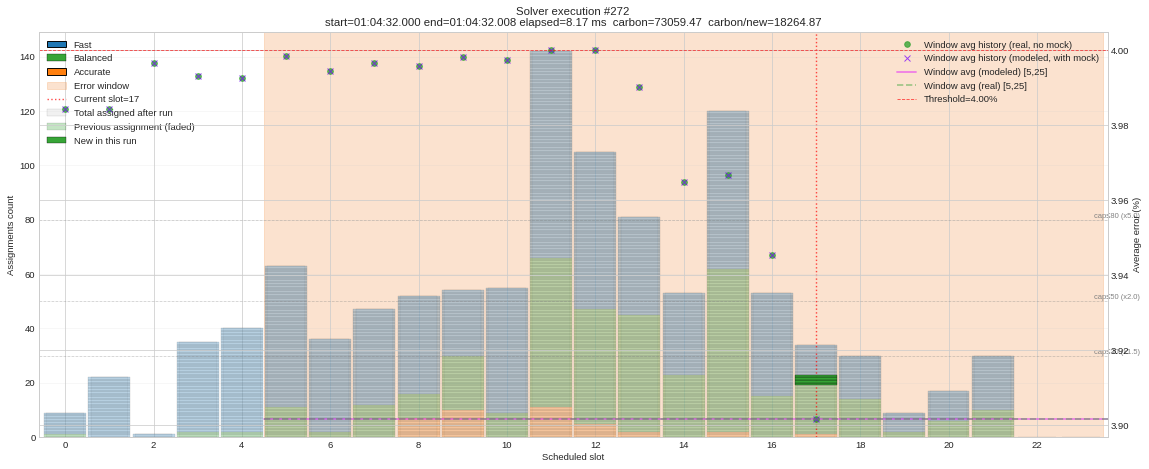

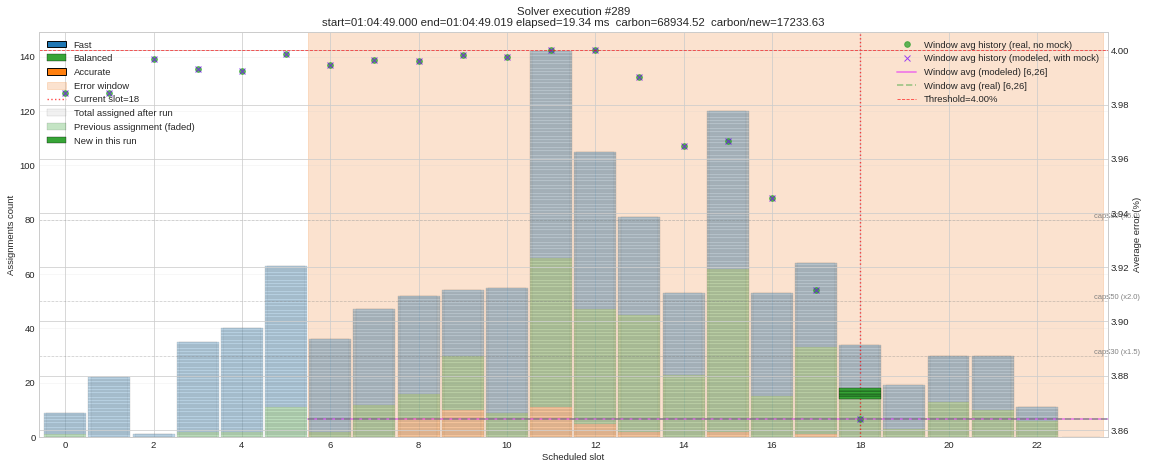

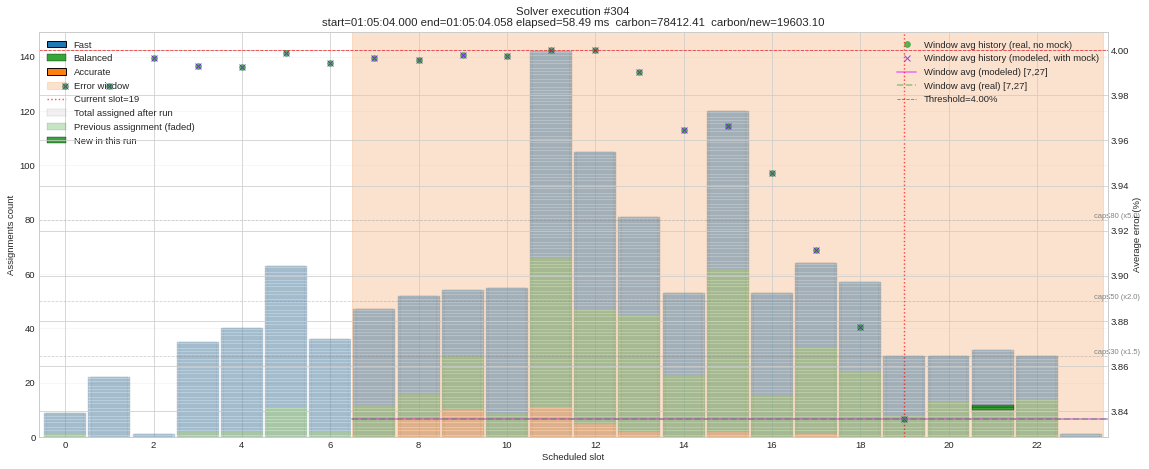

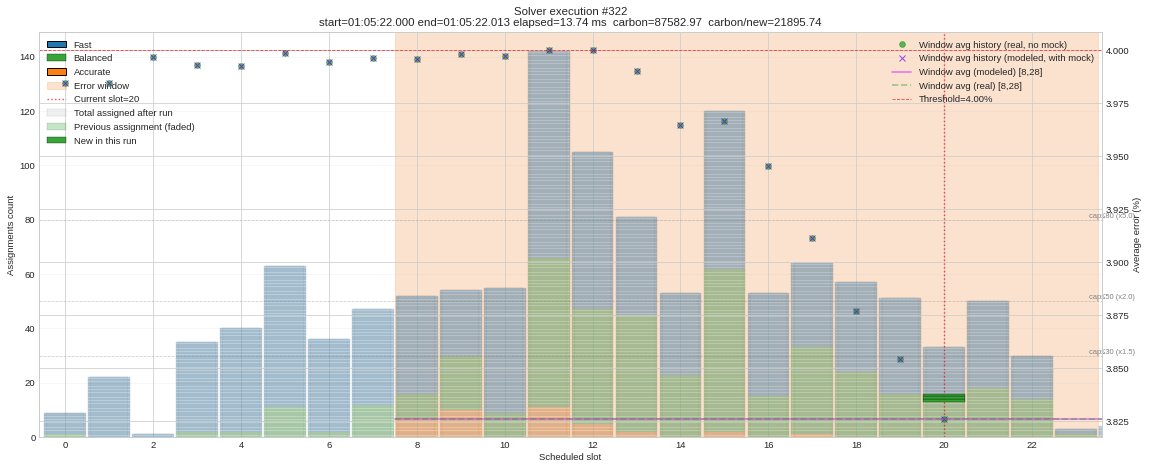

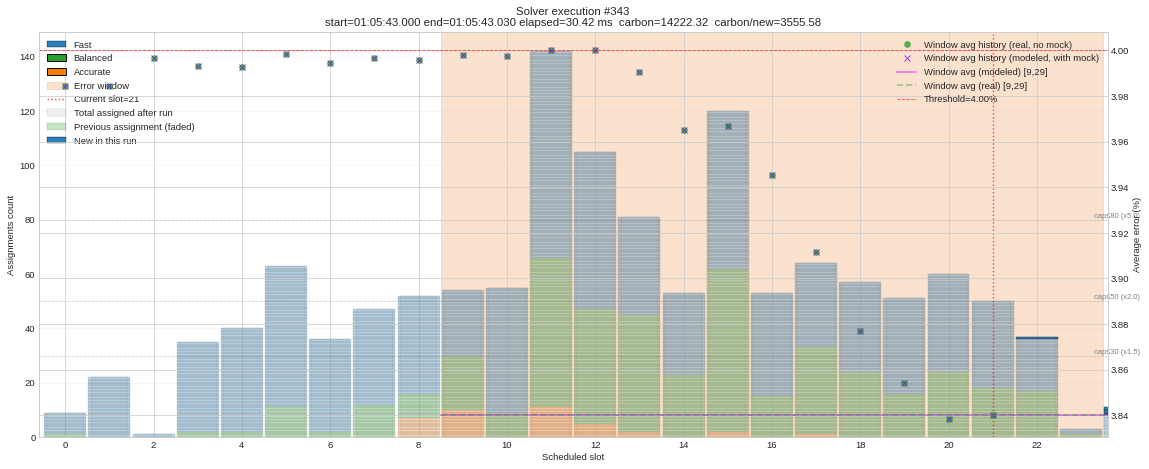

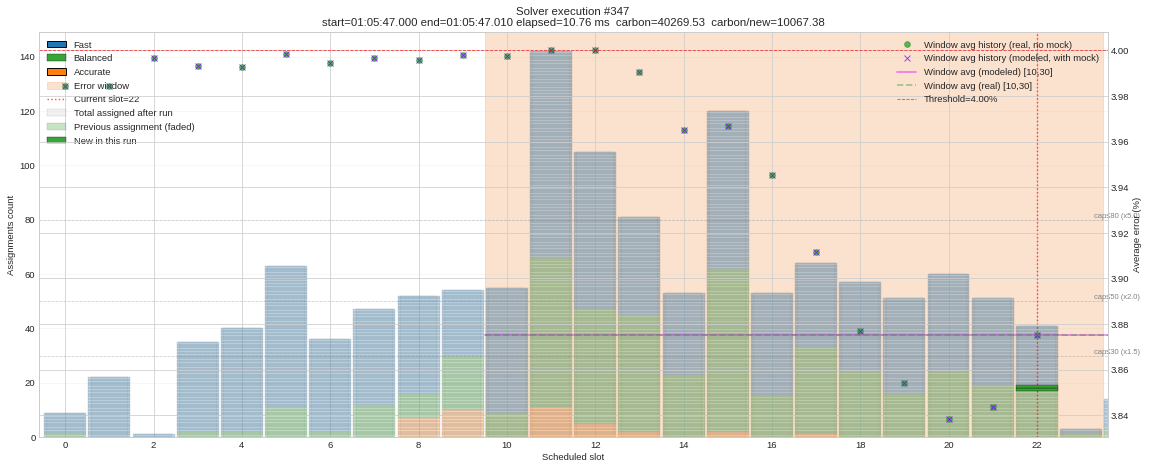

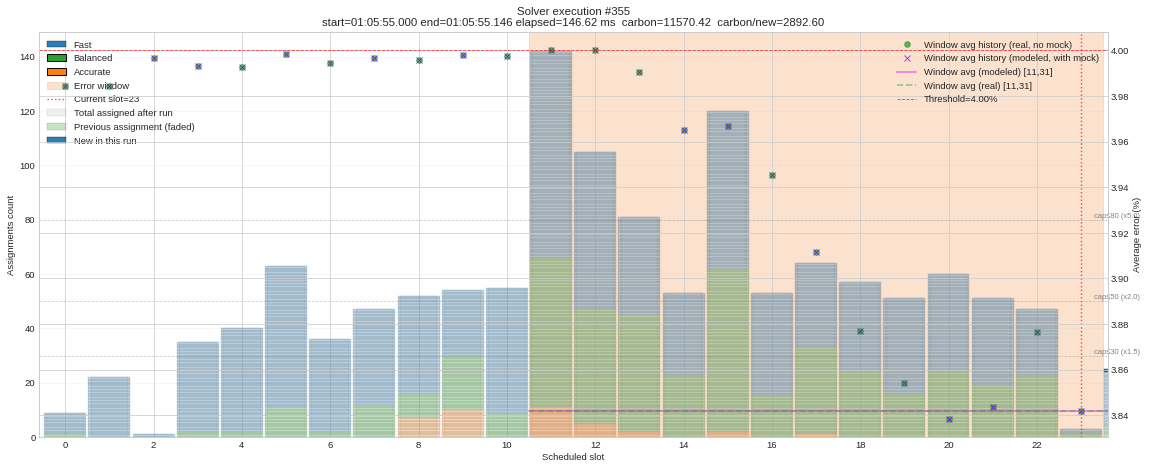

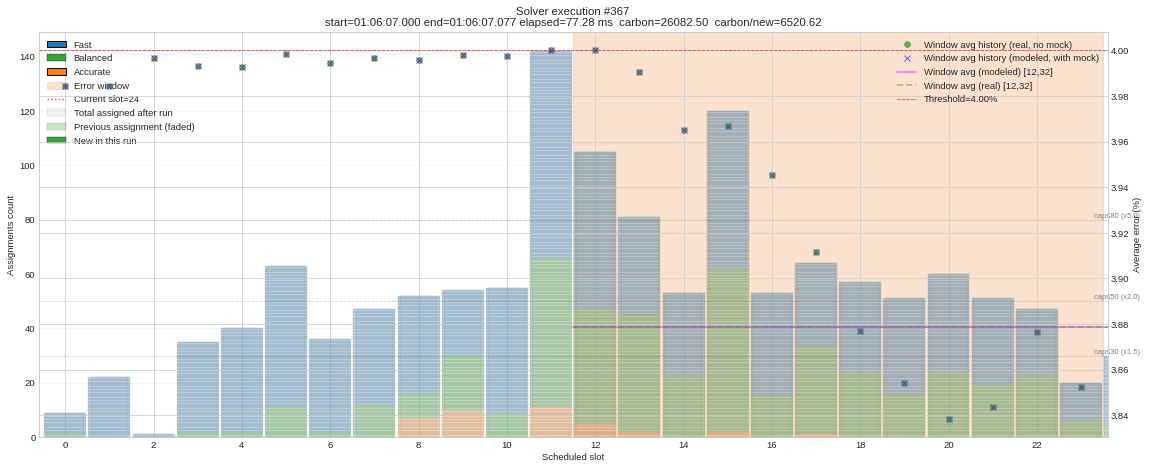

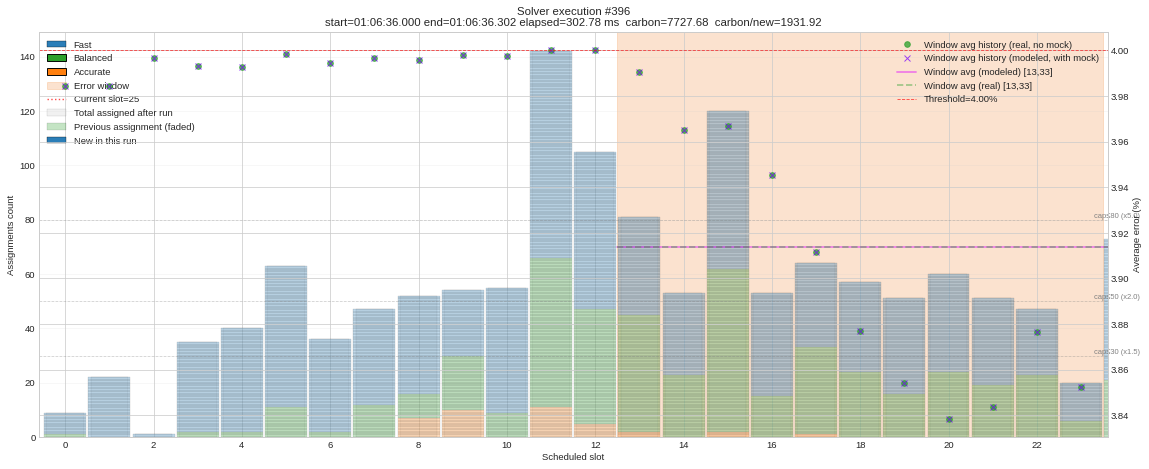

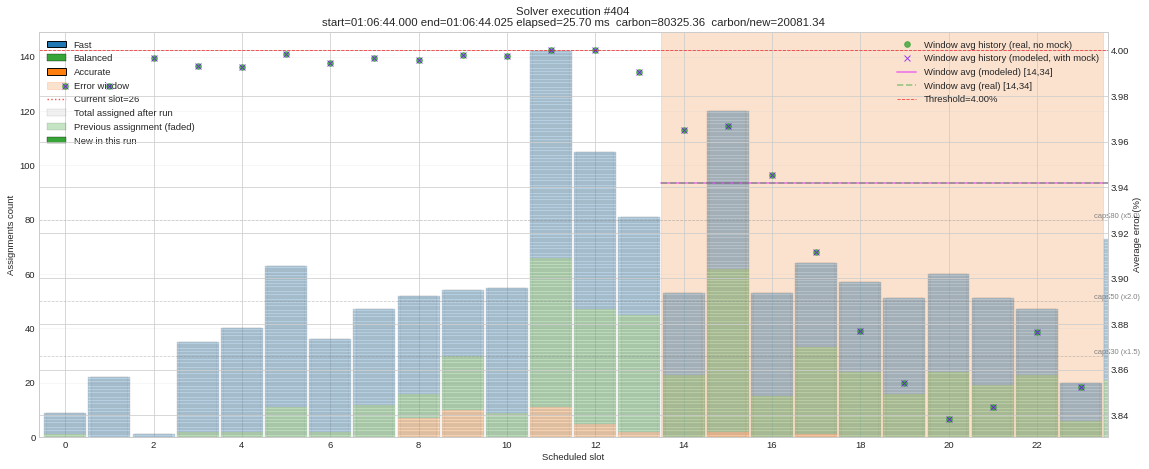

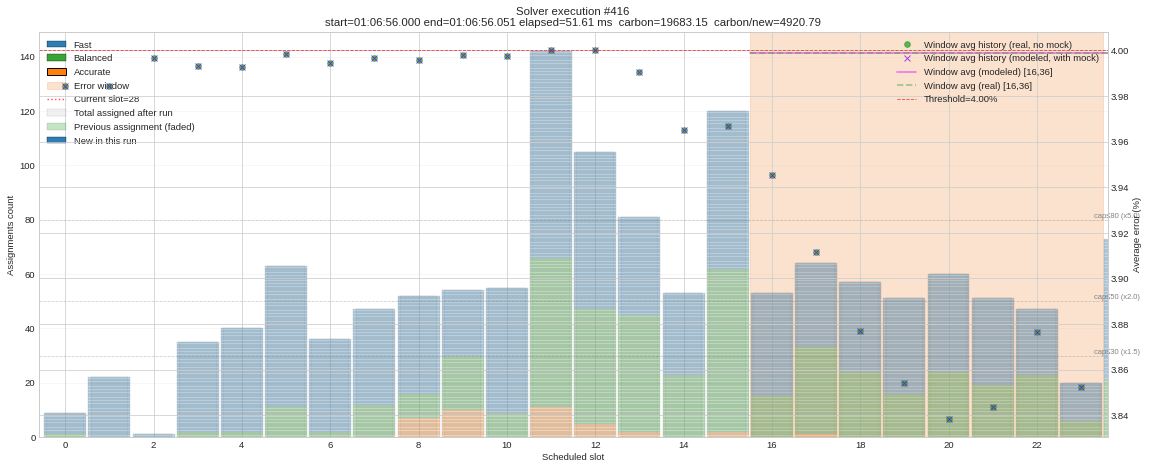

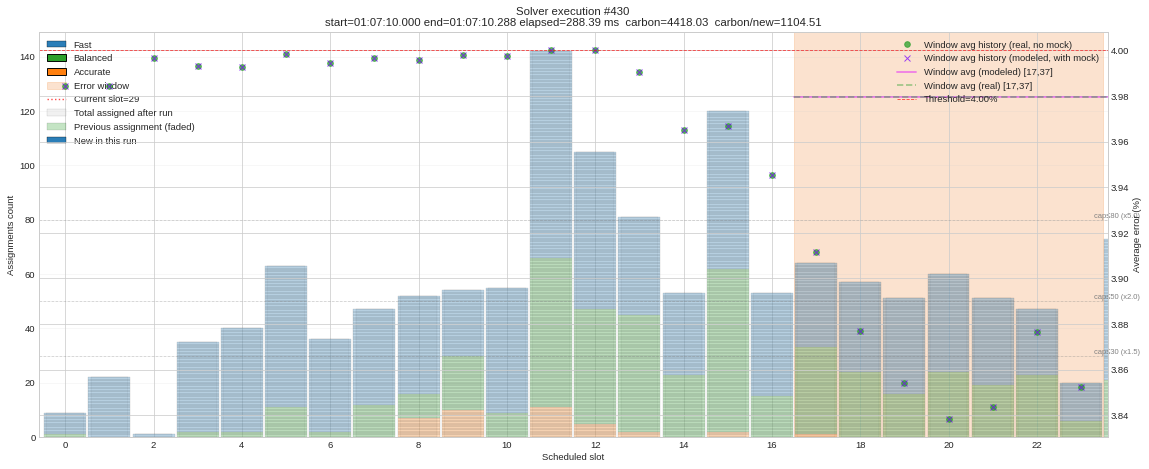

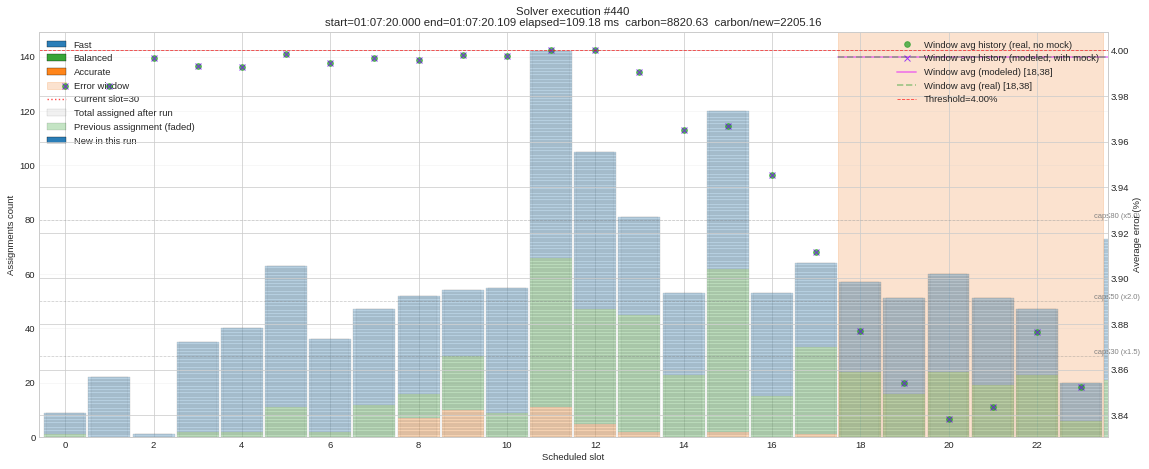

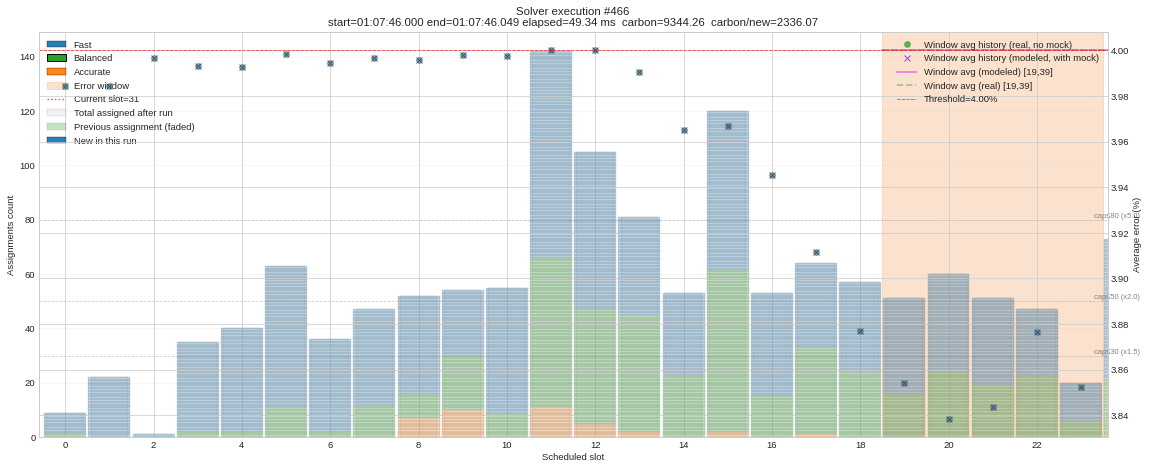

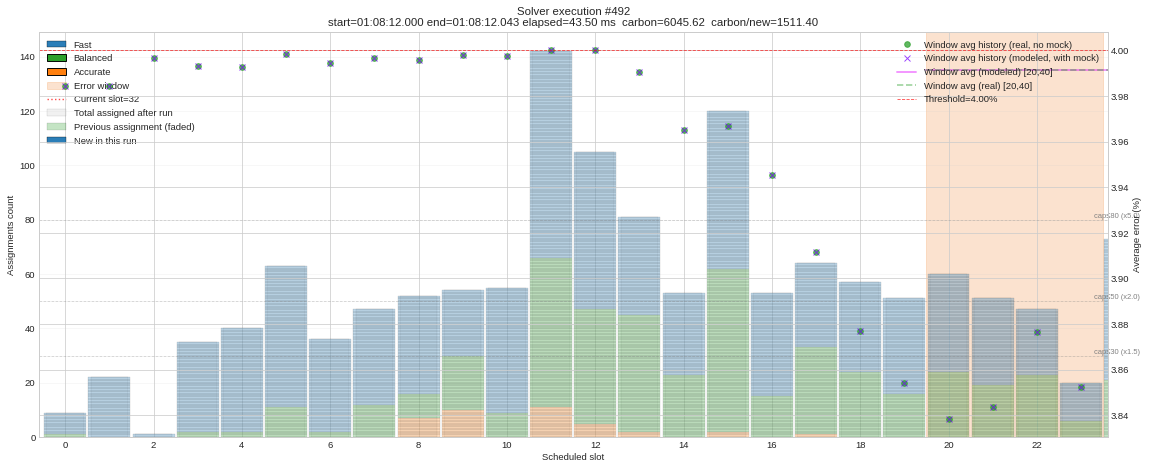

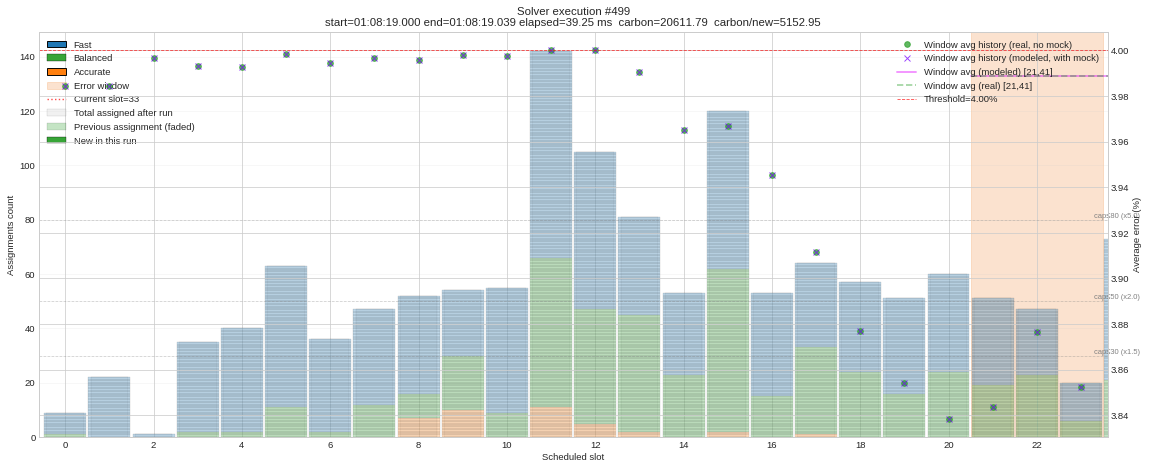

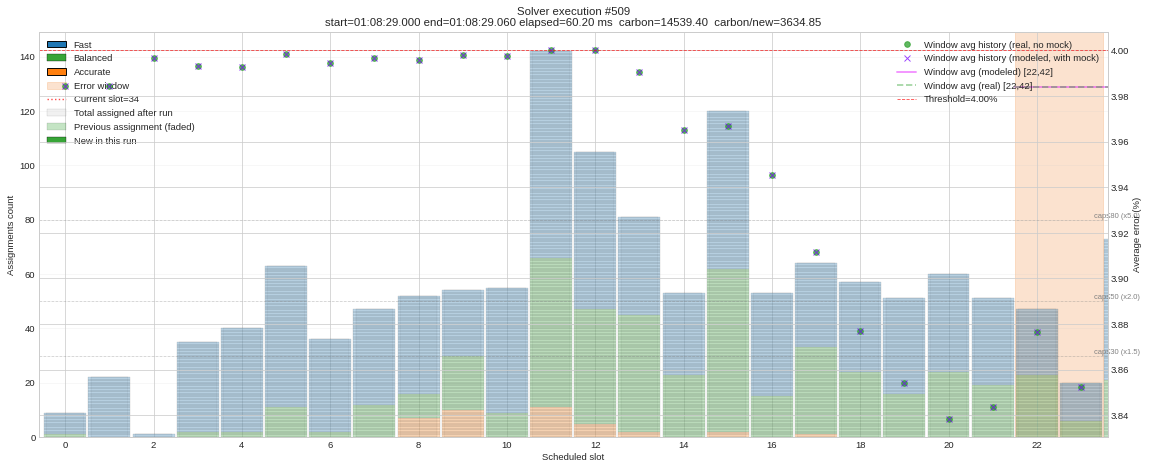

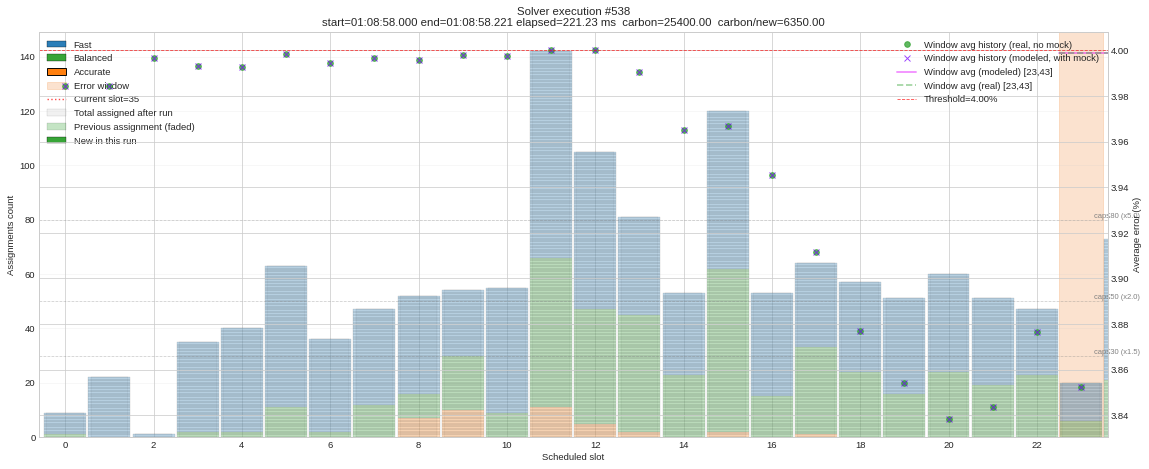

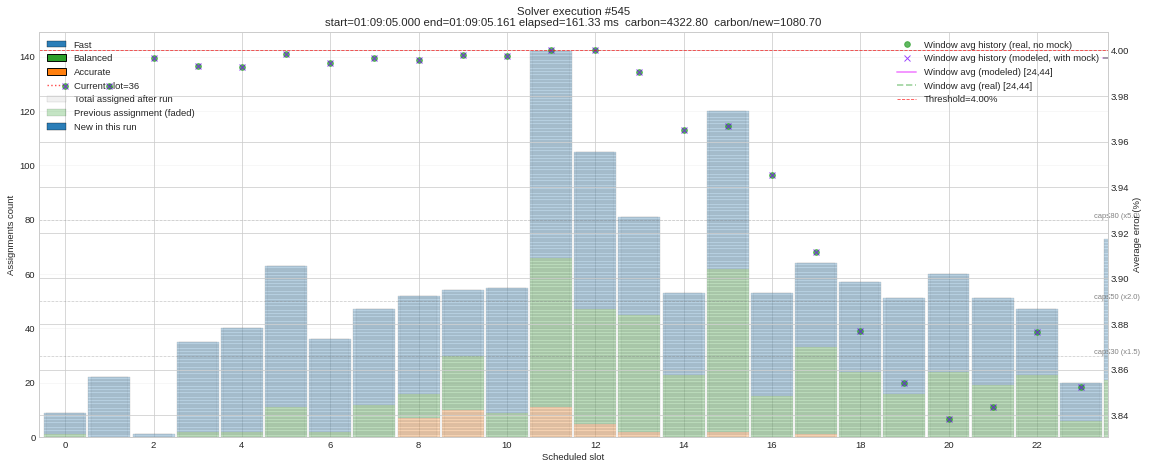

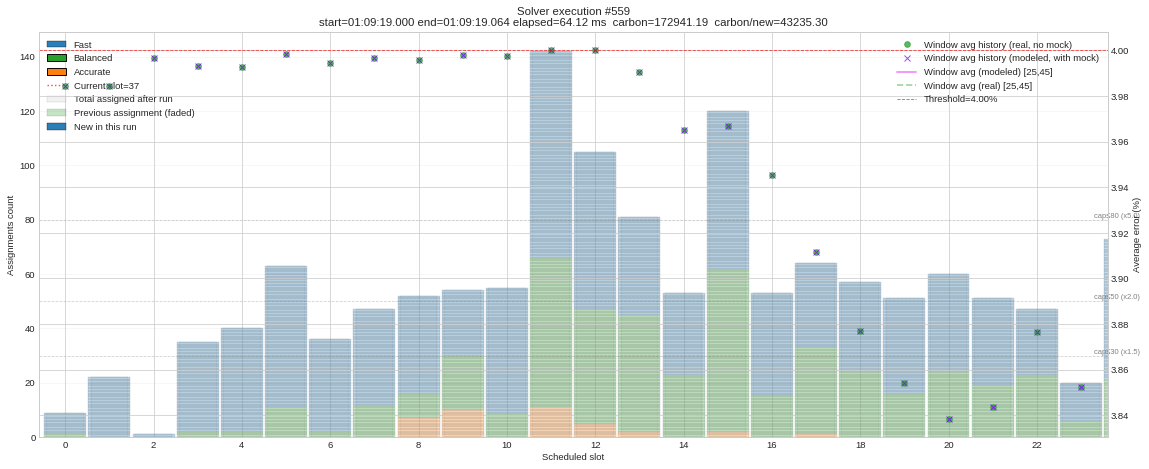

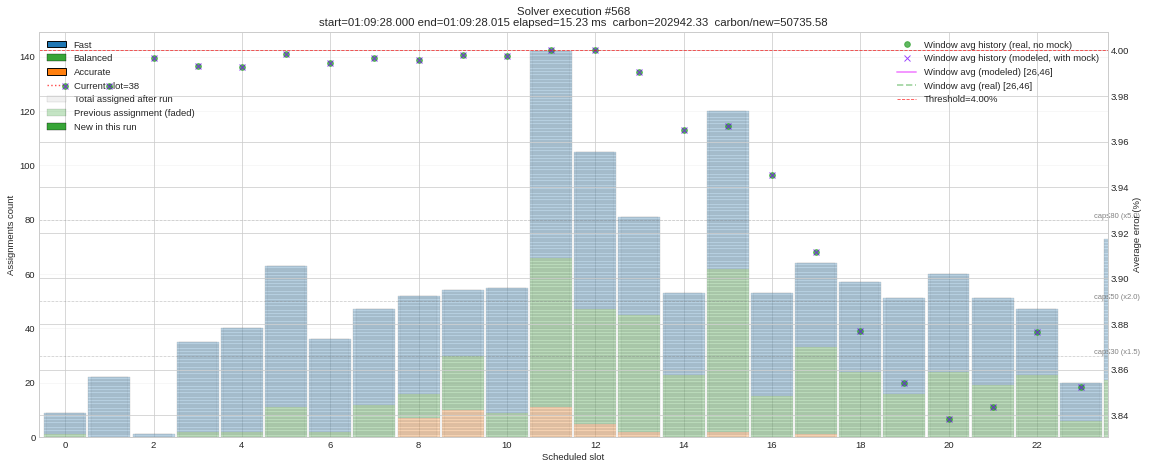

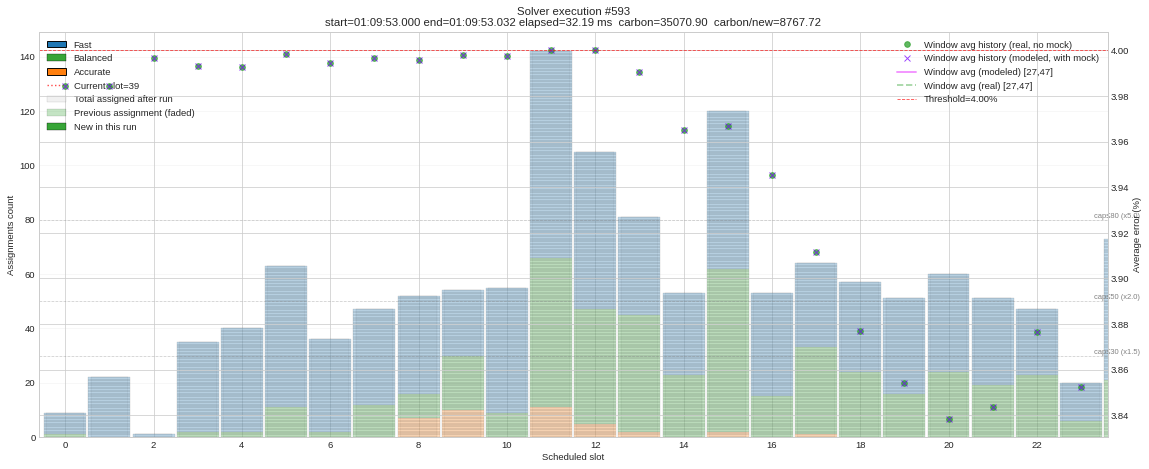

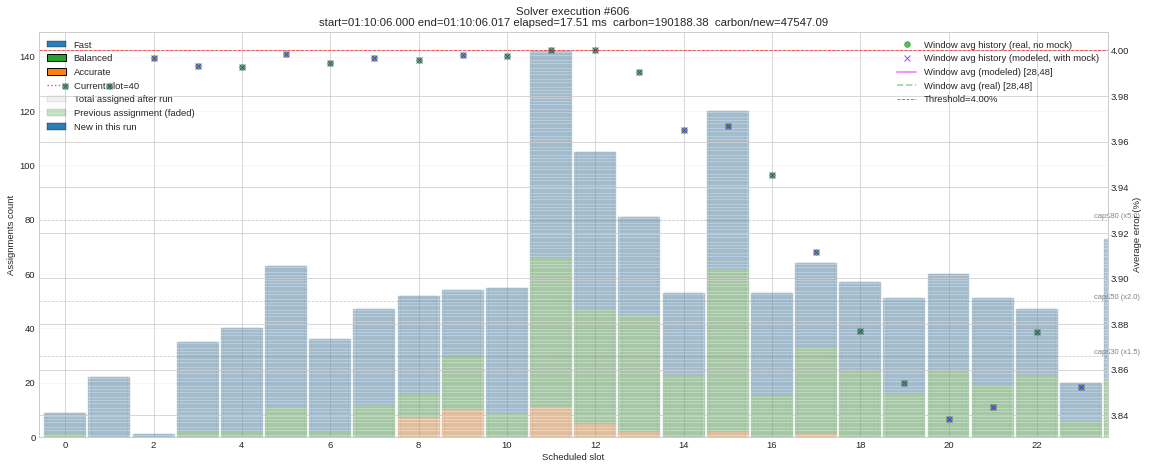

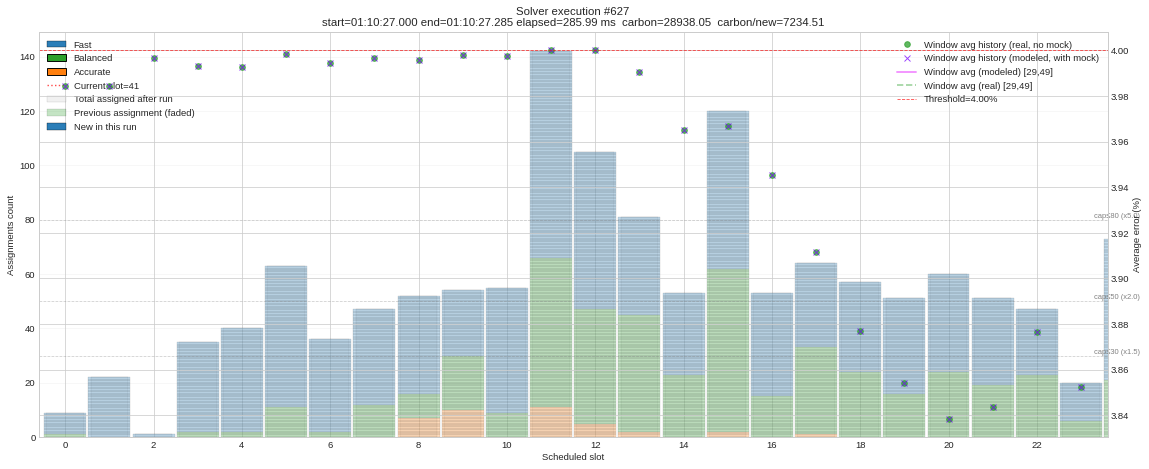

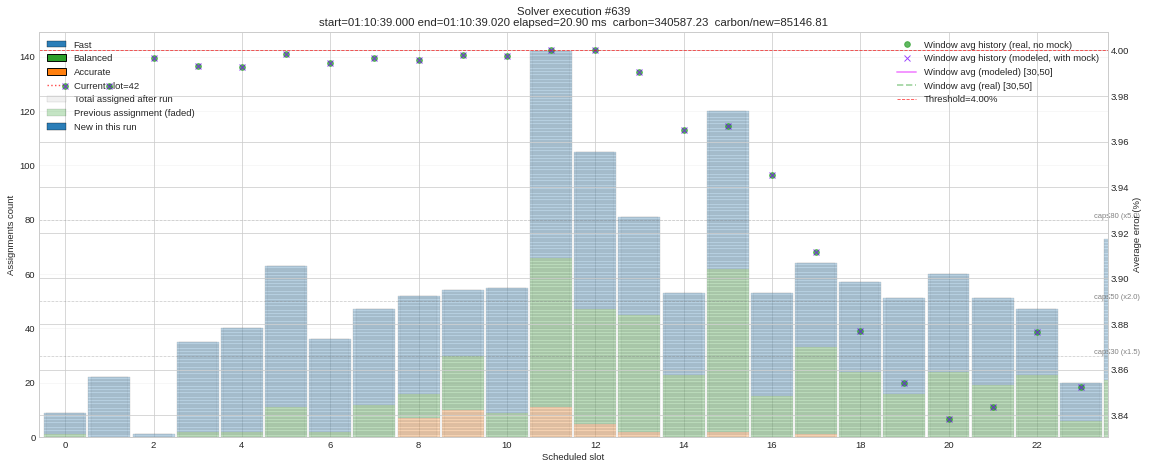

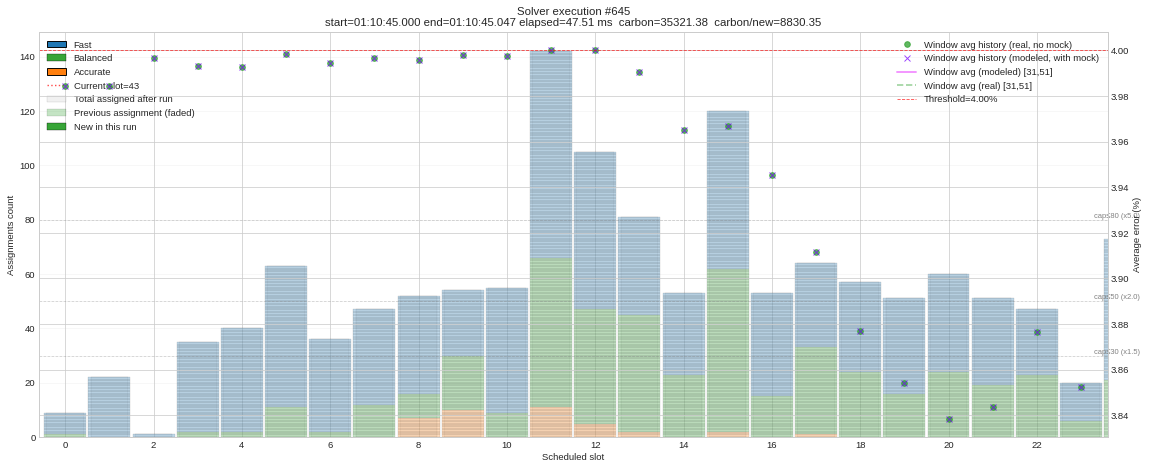

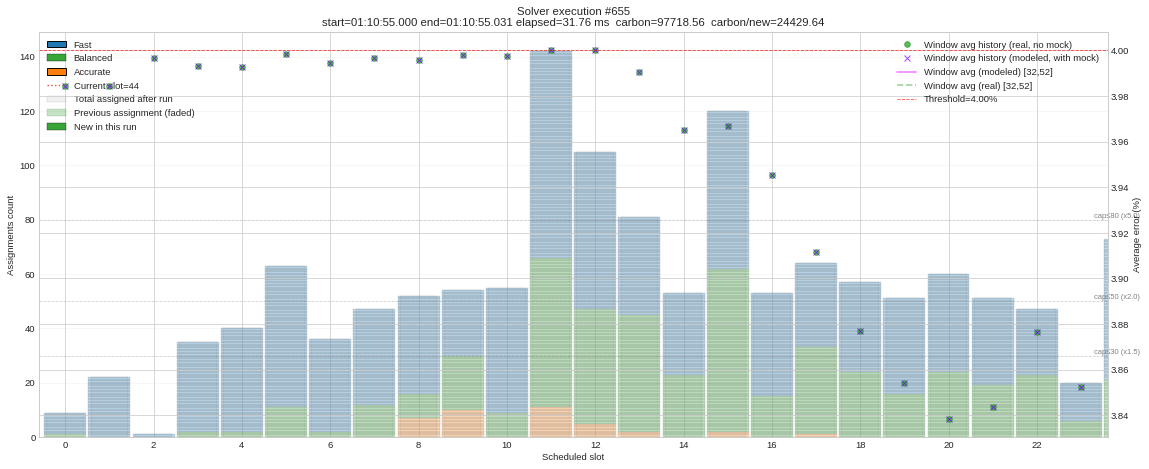

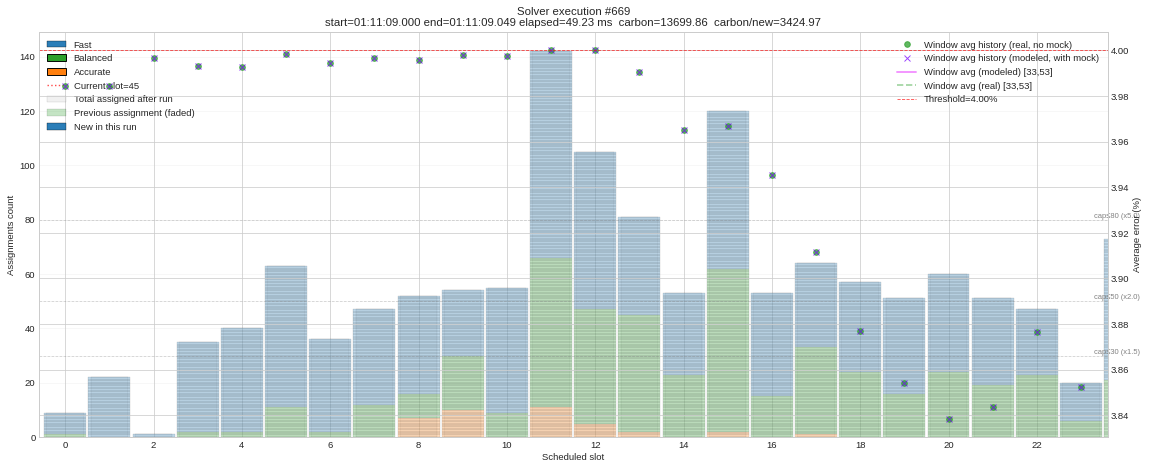

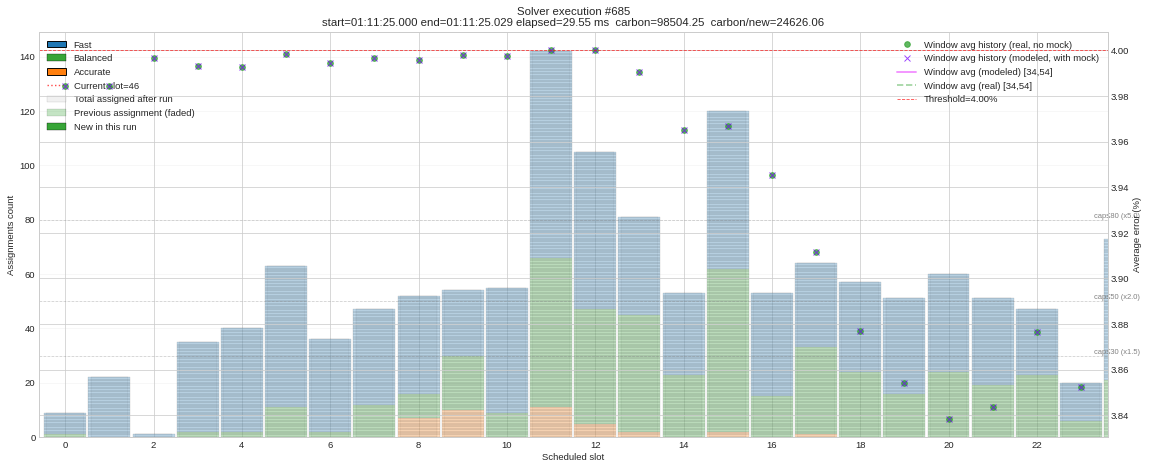

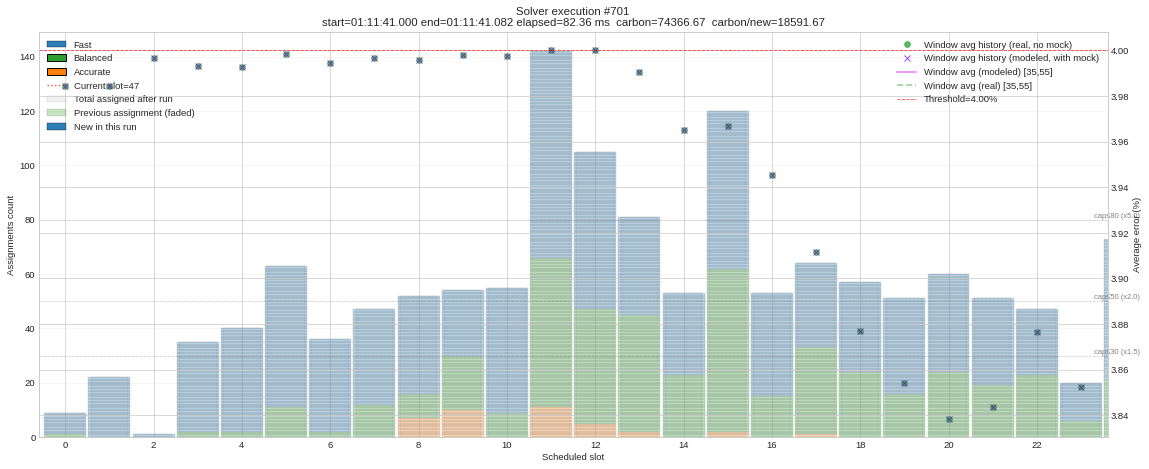

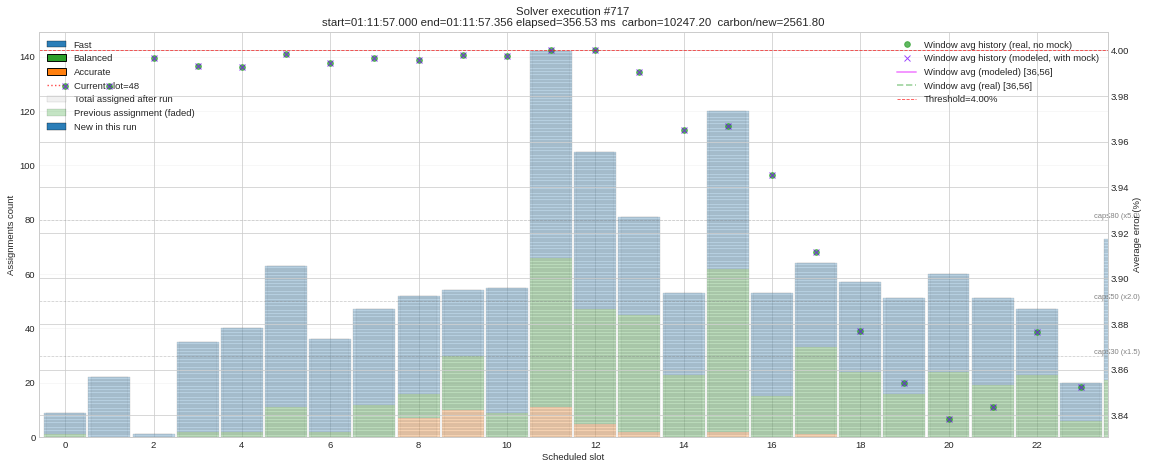

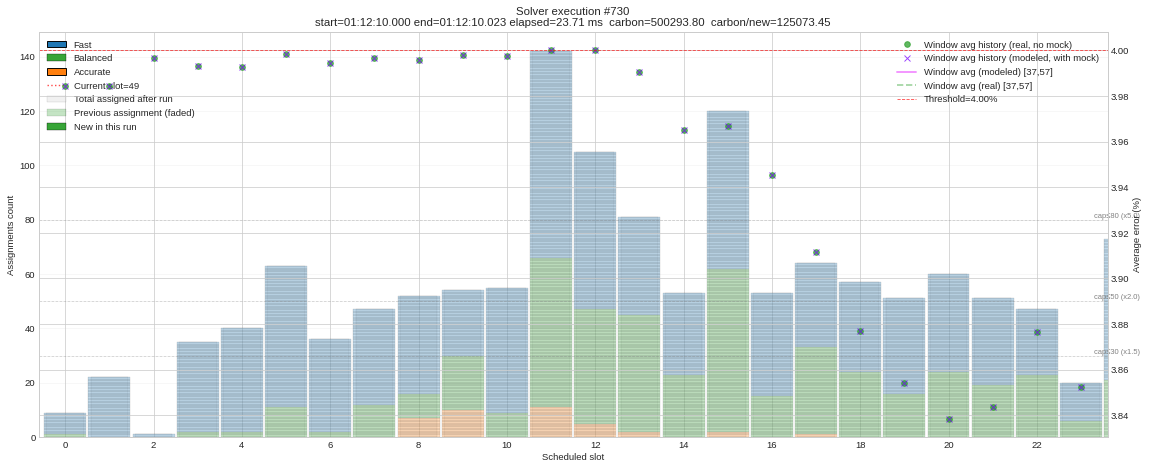

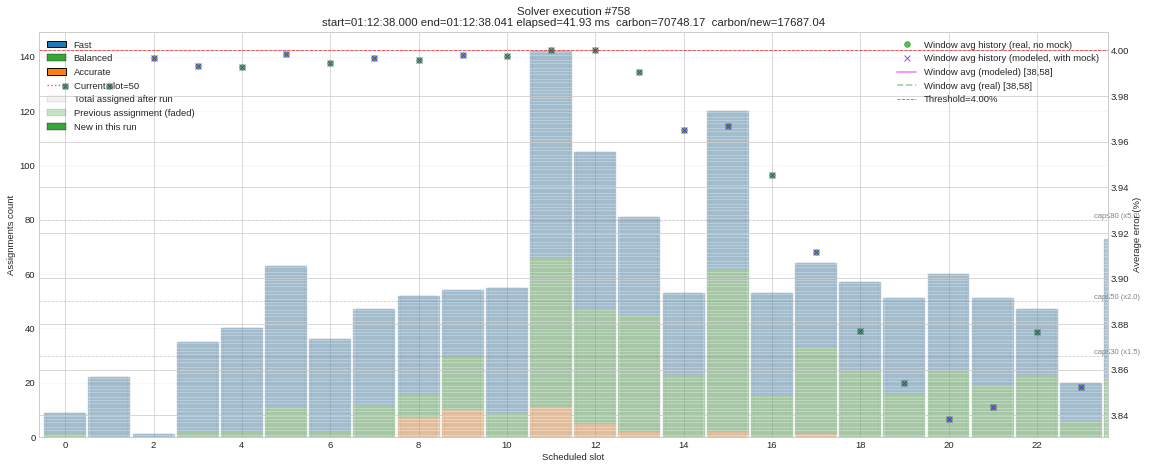

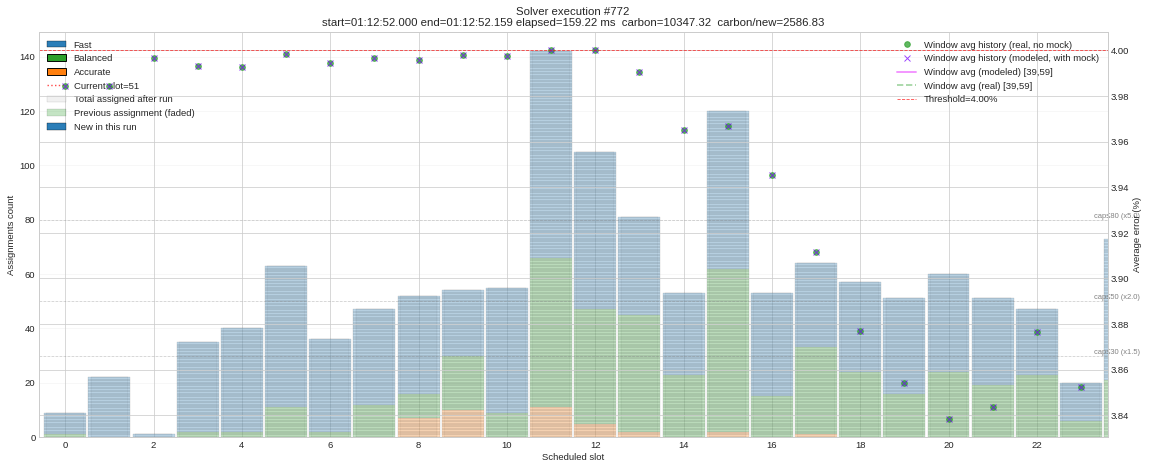

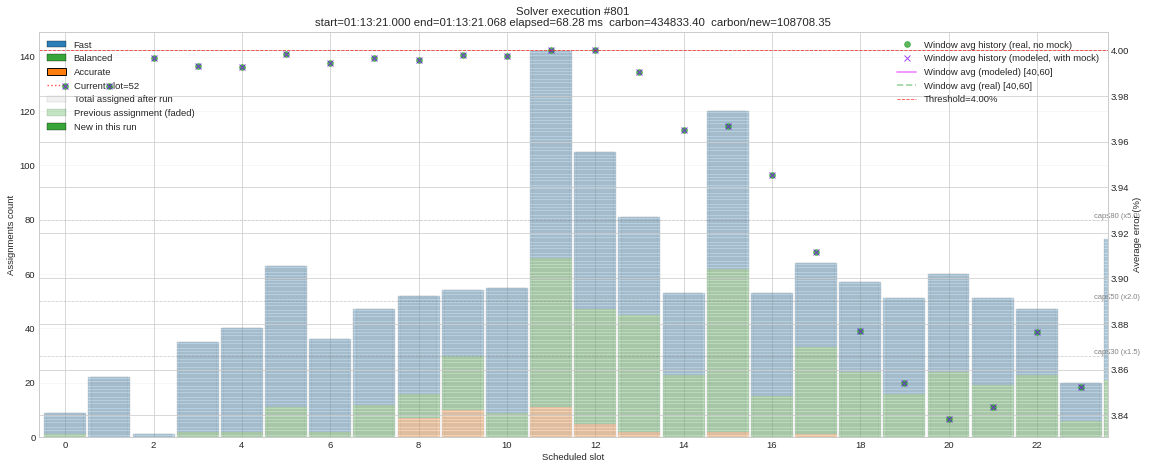

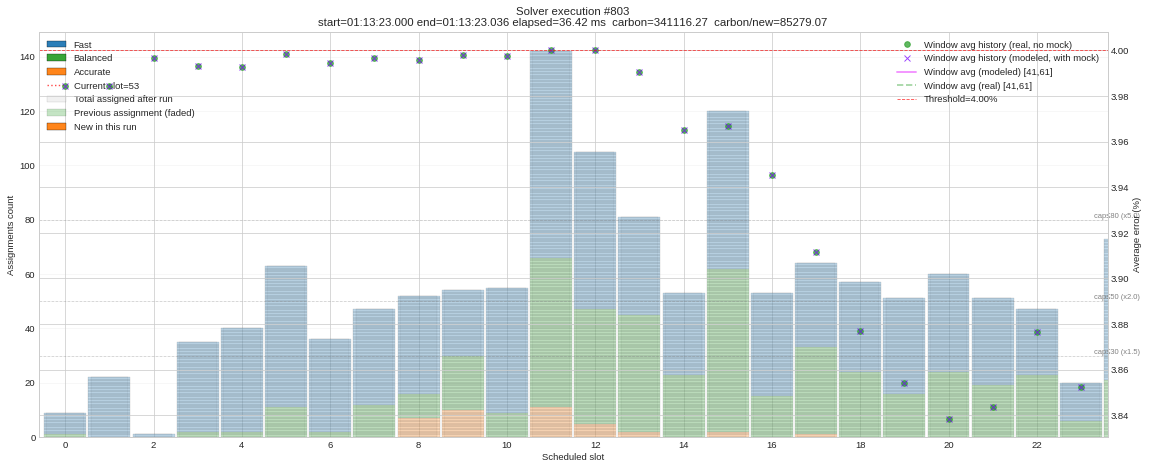

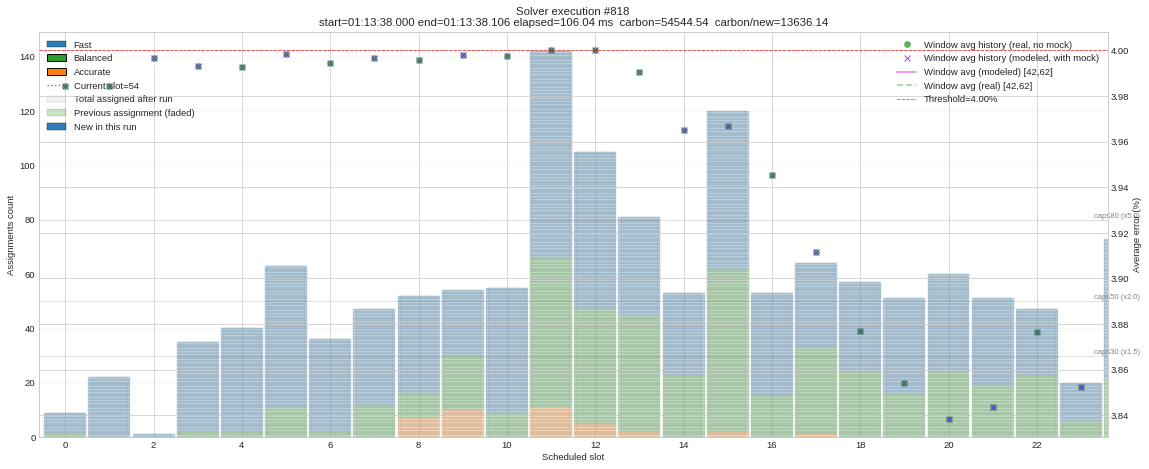

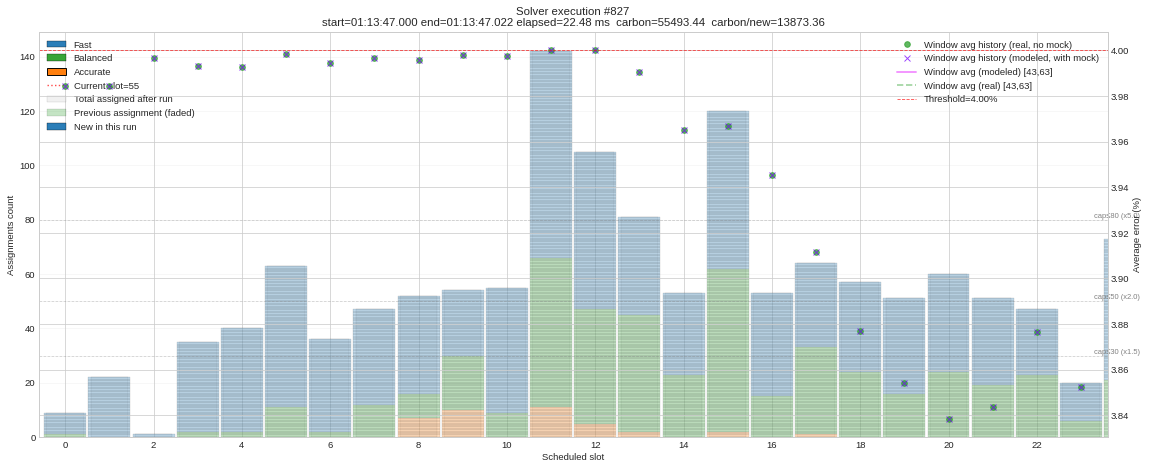

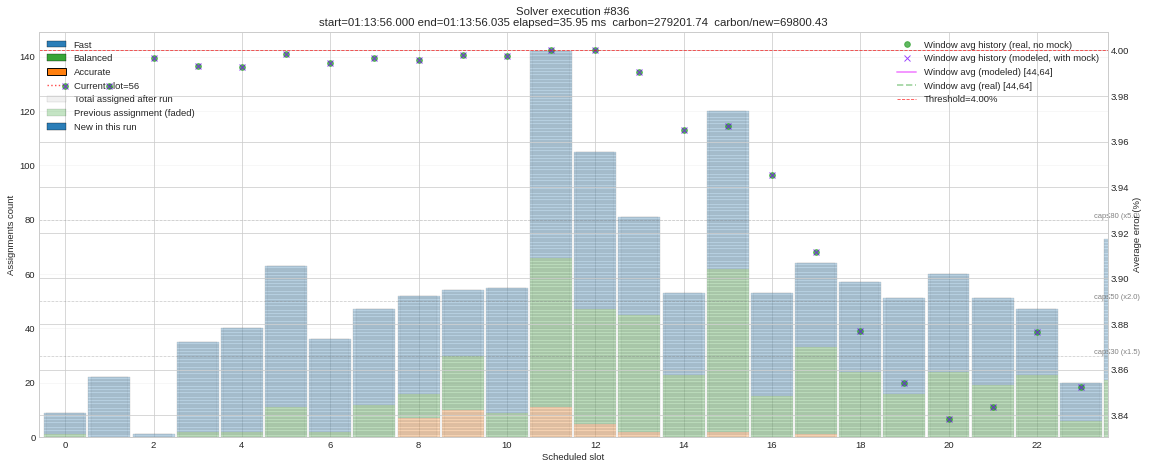

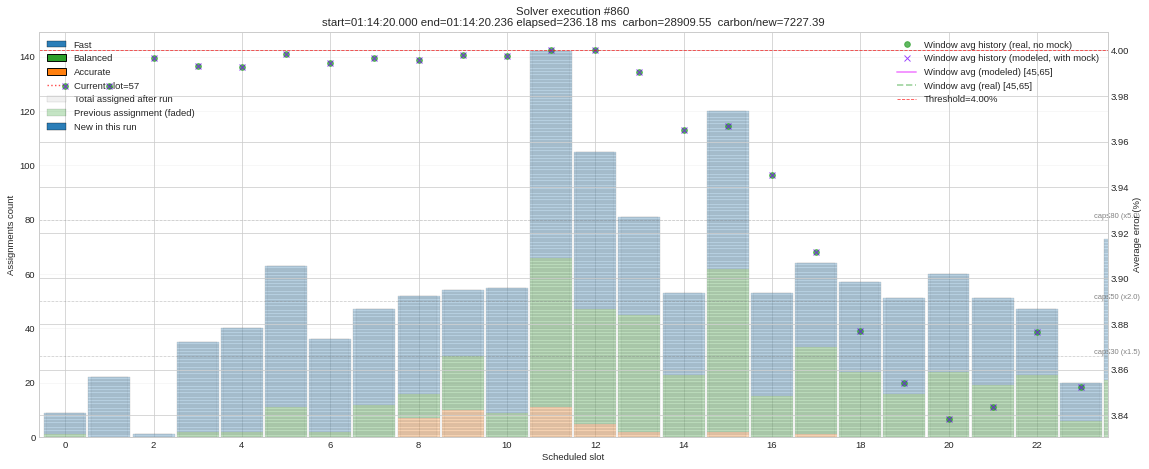

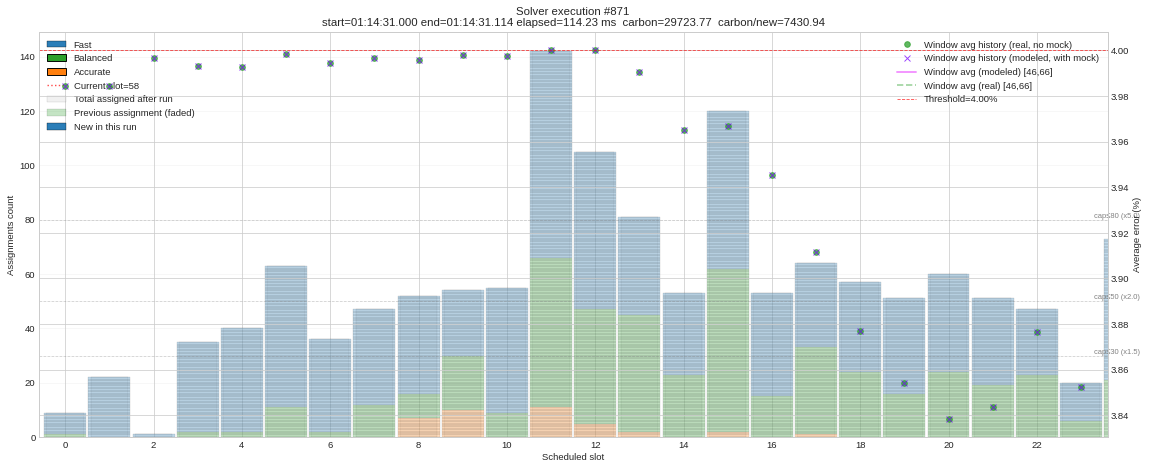

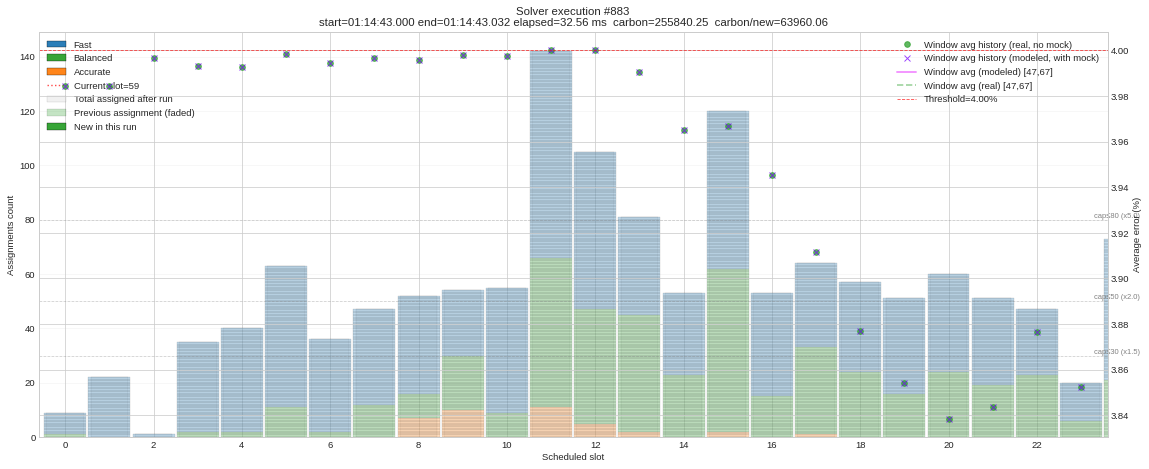

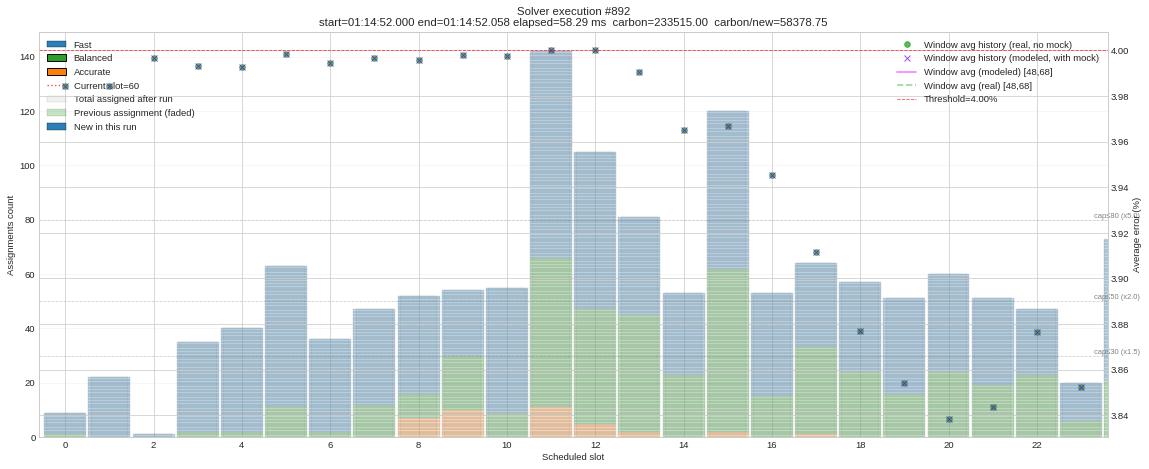

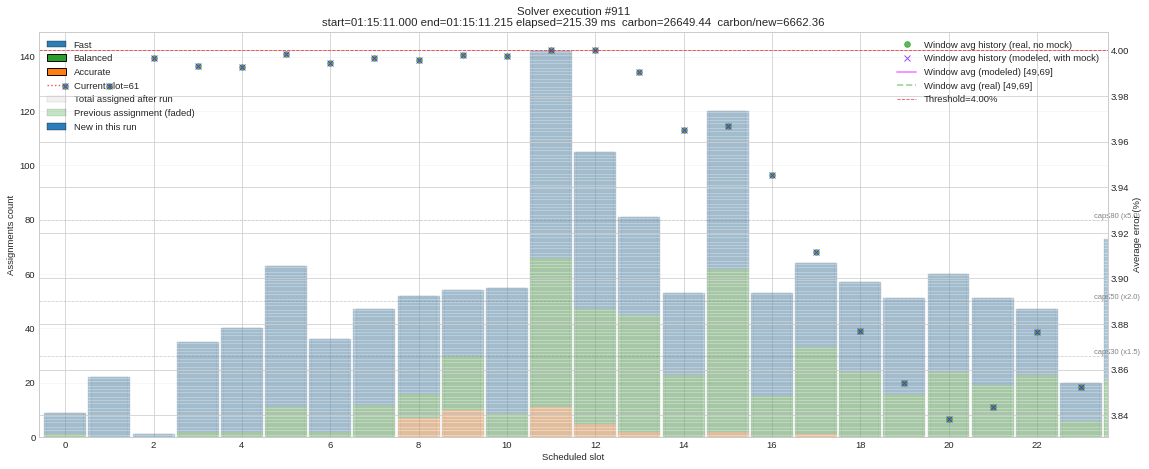

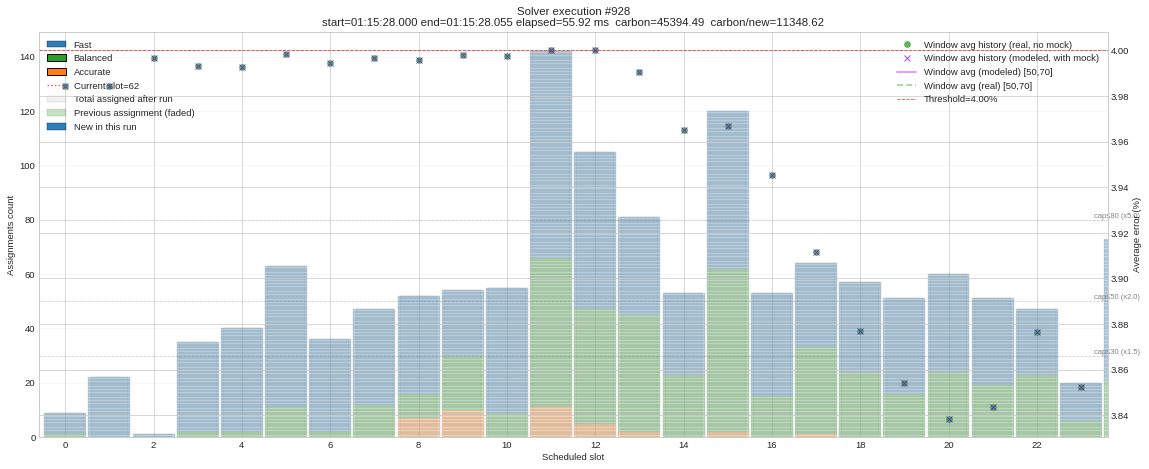

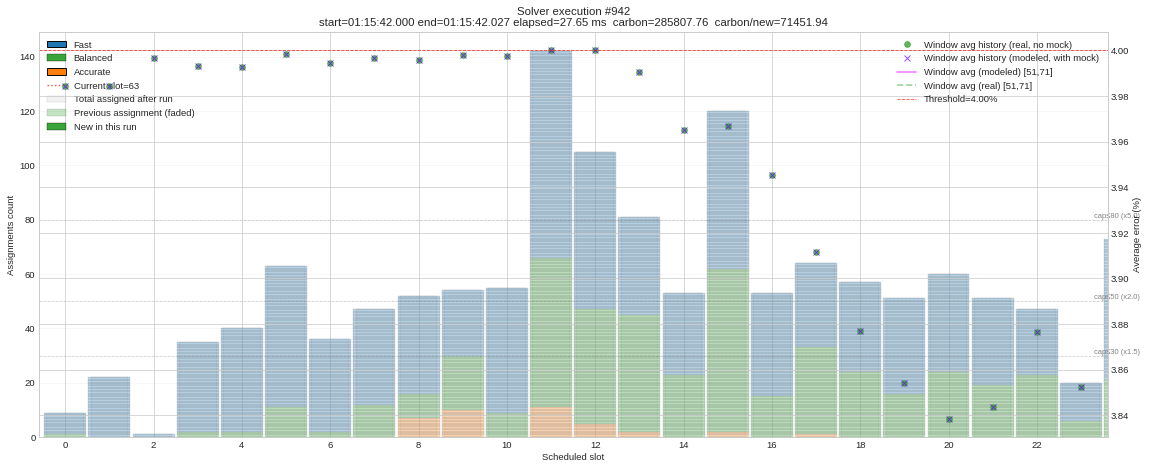

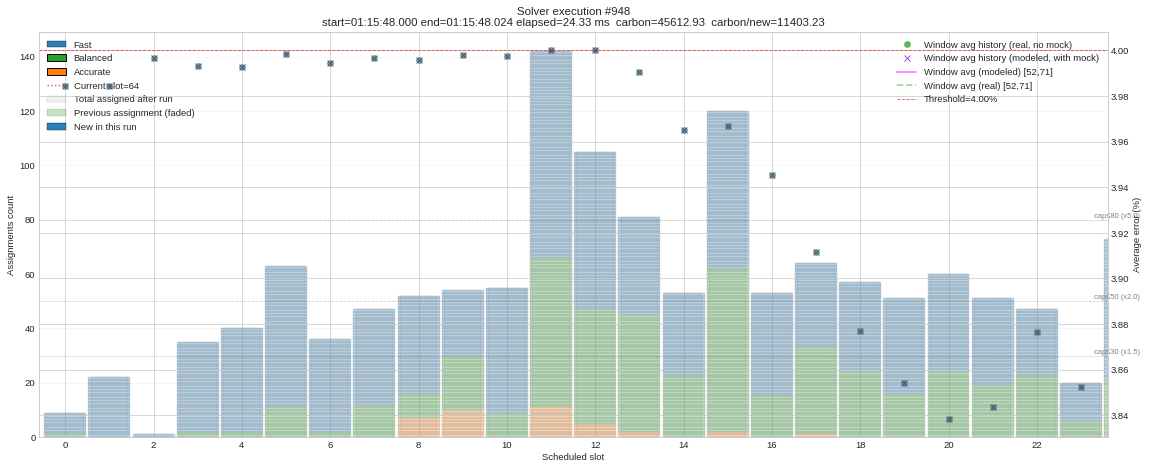

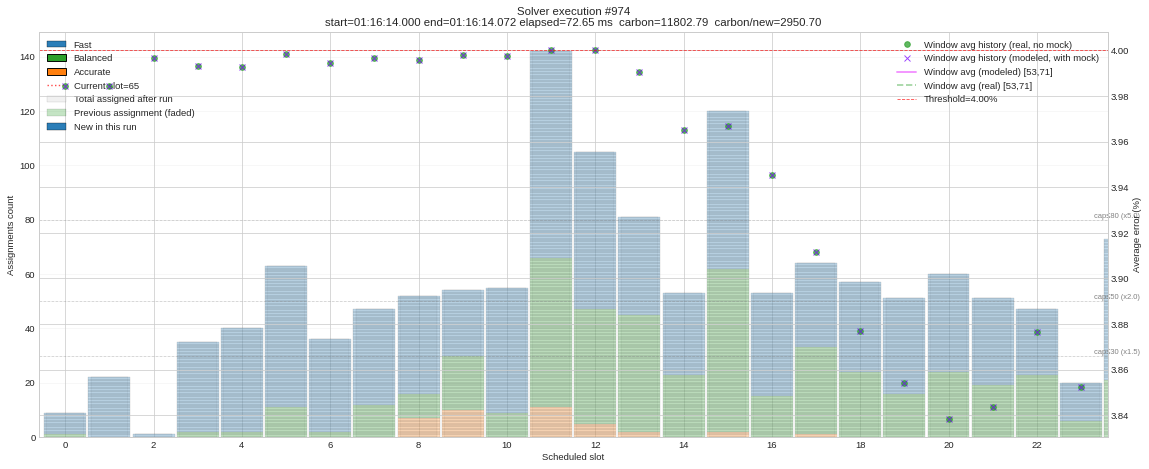

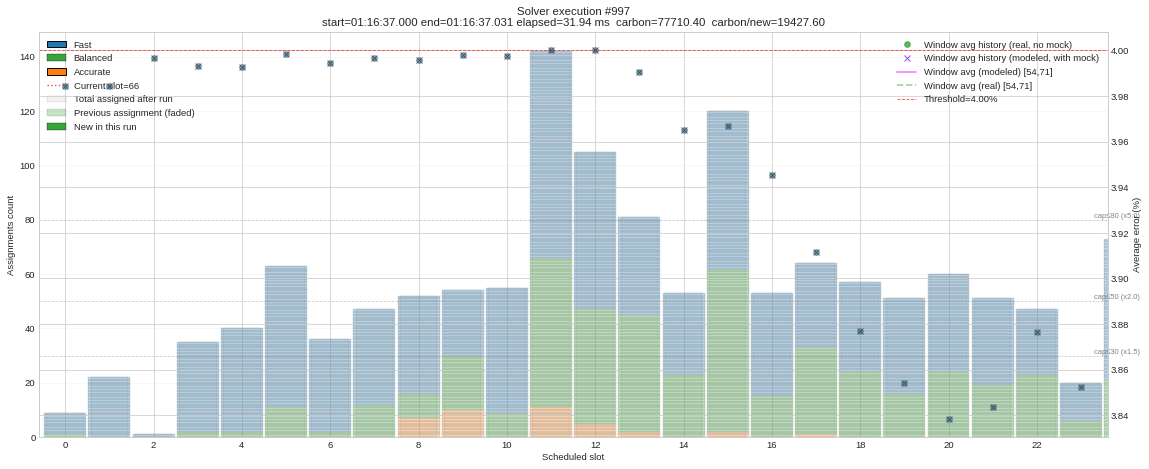

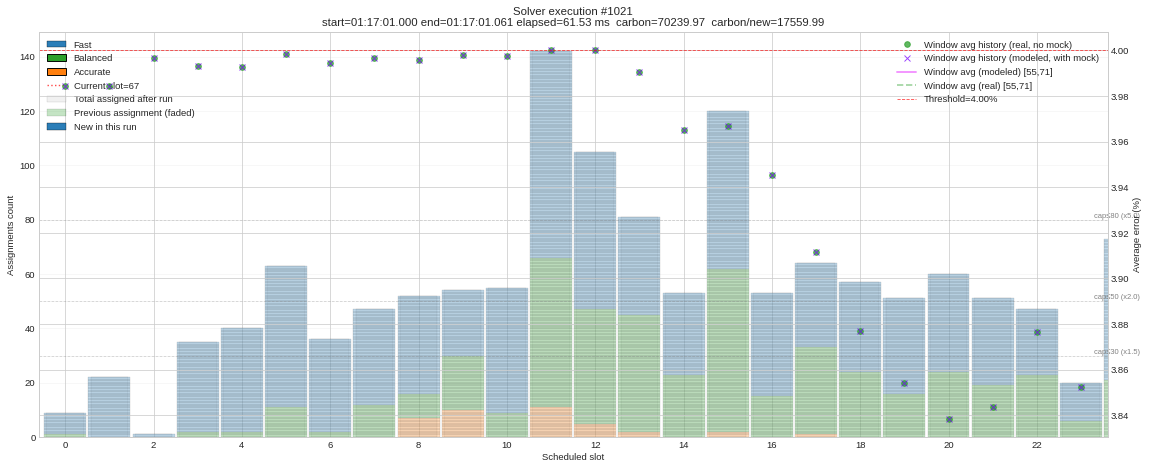

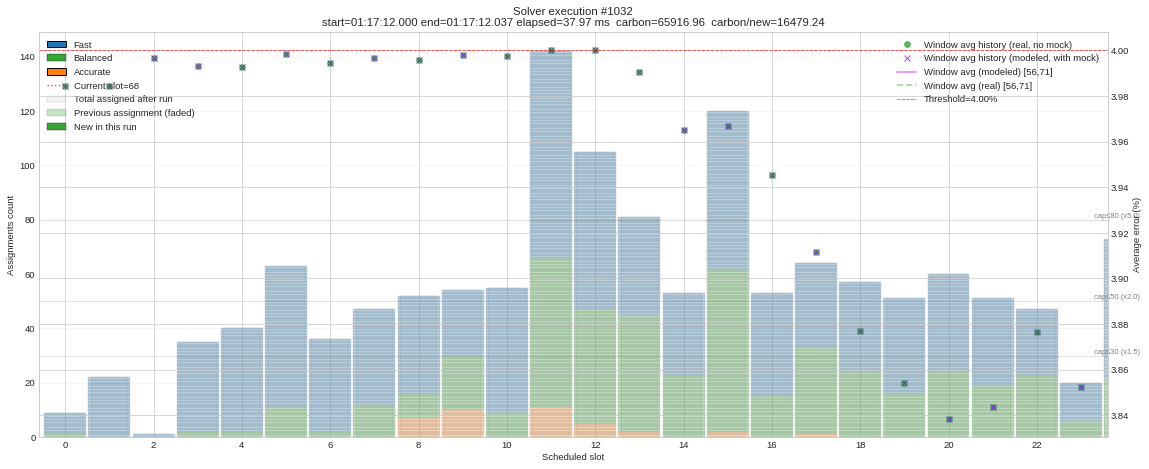

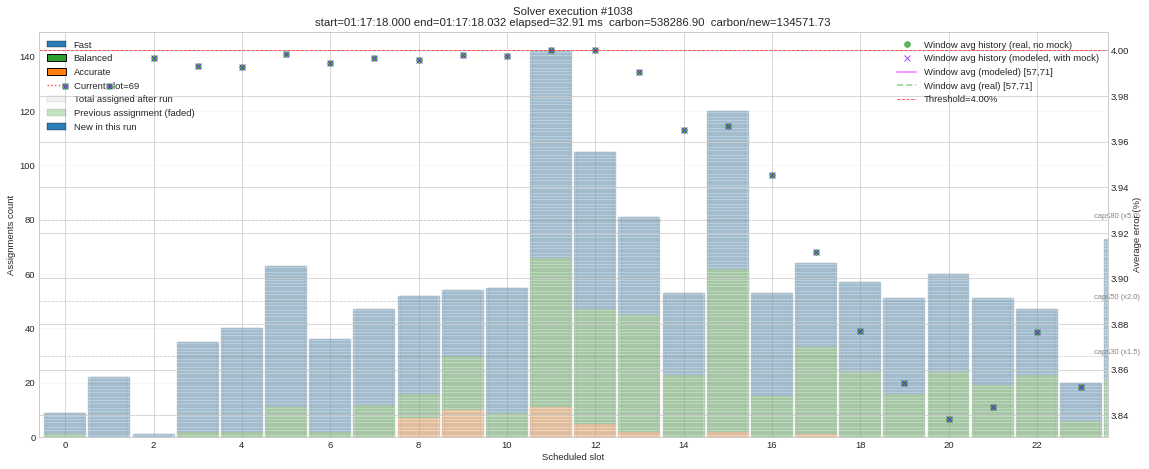

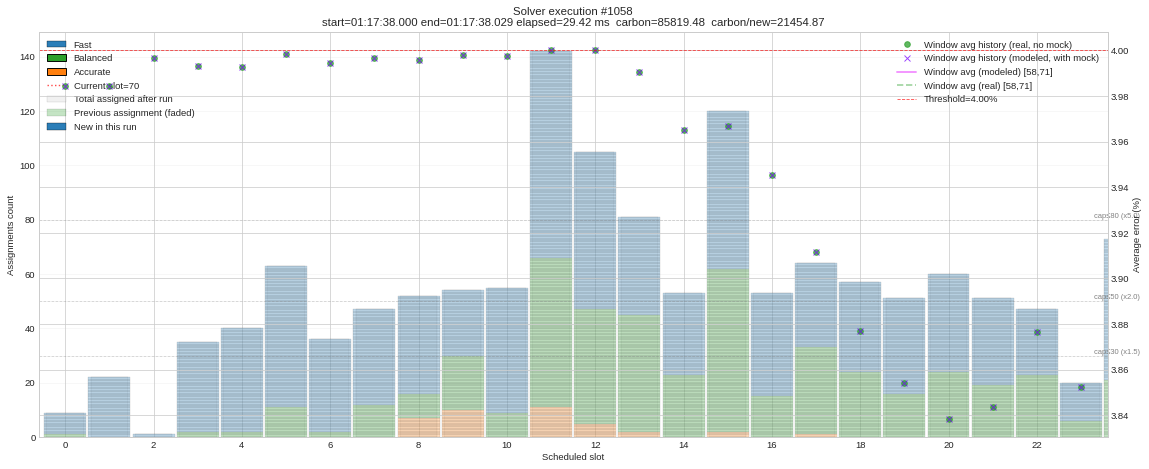

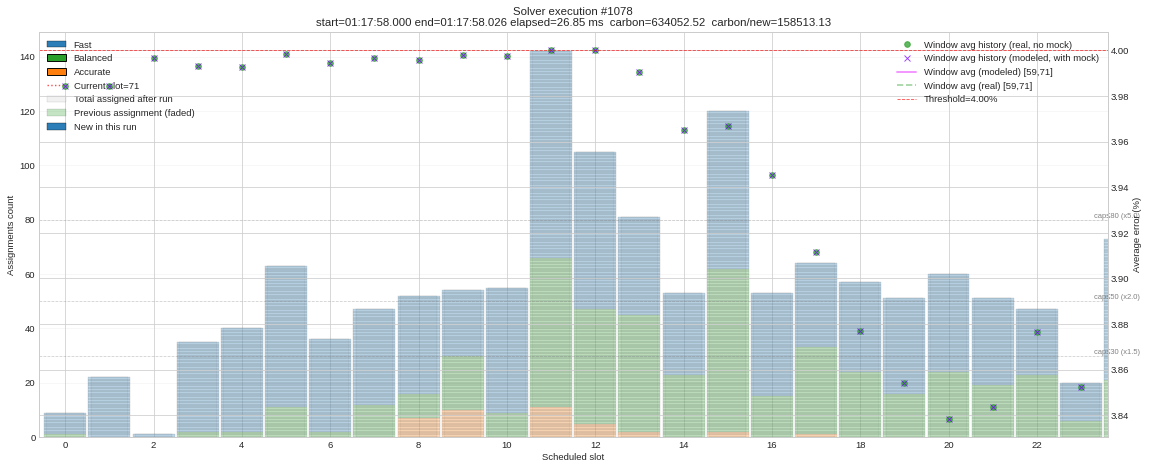

In [19]:
selected_run_ids = select_run_ids(runs_df, mode=RUN_SELECTION_MODE, target_slot=TARGET_SLOT)
if not selected_run_ids:
    raise ValueError("No runs selected with current filters.")

print(
    f"Selected {len(selected_run_ids)} runs for N={SELECTED_N}: "
    f"{selected_run_ids[:8]}{' ...' if len(selected_run_ids) > 8 else ''}"
)

# # Display request text only if the selected runs stay below clutter threshold.
# selected_assignments = assignments_df[assignments_df["run_id"].isin(selected_run_ids)]
# slot_counts = selected_assignments.groupby("scheduled_slot").size()
# max_slot_count = int(slot_counts.max()) if not slot_counts.empty else 0
# SHOW_REQ_TEXT = max_slot_count < 40

# get the number of requests assigned to each slot examining assignment_df, and counting only the "latest" slot assigned to each request across all runs, and display request text only if the max count is below clutter threshold
unique_requests = assignments_df[assignments_df["run_id"].isin(selected_run_ids)].groupby("request_id").apply(lambda df: df.sort_values("scheduled_slot").iloc[-1])
slot_counts = unique_requests.groupby("scheduled_slot").size()
max_slot_count = int(slot_counts.max()) if not slot_counts.empty else 0
SHOW_REQ_TEXT = max_slot_count < 40
print(max_slot_count)



for rid in selected_run_ids:
    fig = plot_solver_execution_stacked(
        run_id=rid,
        runs_df=runs_df,
        assignments_df=assignments_df,
        slot_metrics_df=None,
        flavour_colors=FLAVOUR_COLORS,
        show_req_text=SHOW_REQ_TEXT,
        total_slots=total_slots,
    )
    plt.show()


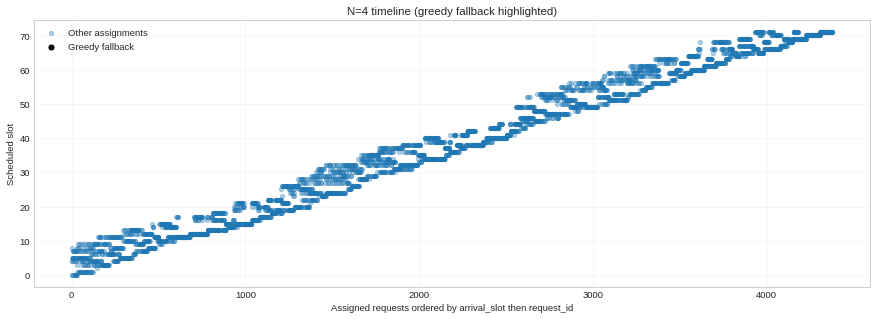

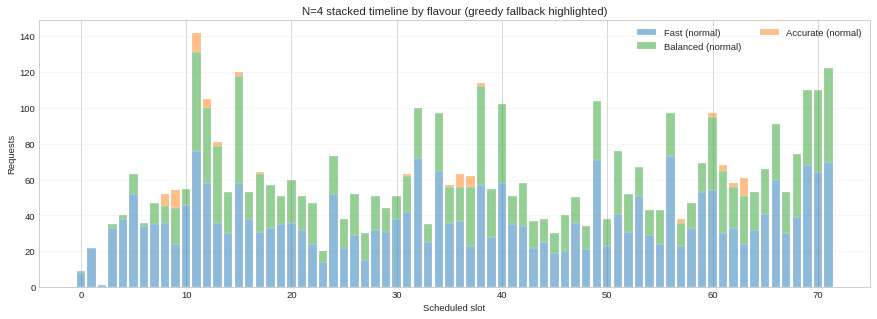

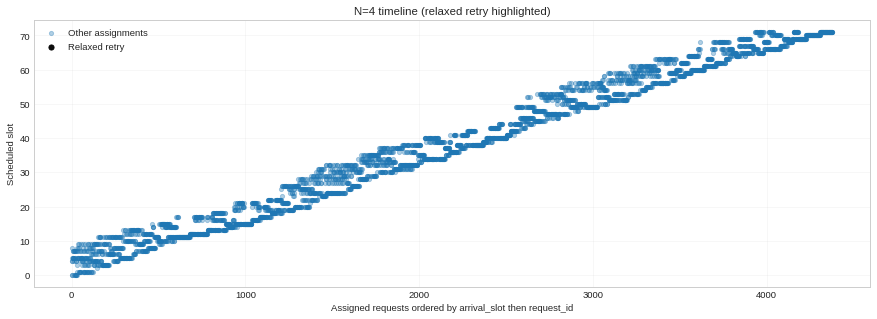

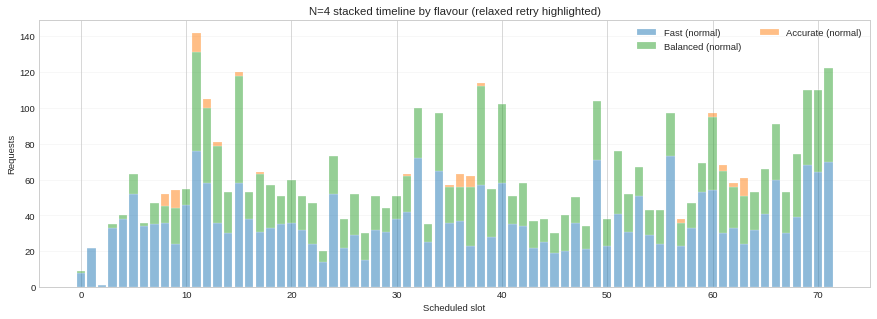

In [20]:
# End-to-end assigned-request timelines for selected N.
def _plot_scatter_timeline(local, flag_mask, title, dark_label):
    fig, ax = plt.subplots(figsize=(13, 4.8))
    x = local.index.to_numpy()
    y = local["scheduled_slot"].to_numpy()
    flags = flag_mask.to_numpy()

    ax.scatter(x[~flags], y[~flags], s=20, alpha=0.35, color="tab:blue", label="Other assignments")
    ax.scatter(x[flags], y[flags], s=30, alpha=0.95, color="black", label=dark_label)

    ax.set_xlabel("Assigned requests ordered by arrival_slot then request_id")
    ax.set_ylabel("Scheduled slot")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.2)
    plt.tight_layout()


def _plot_stacked_timeline(local, flag_mask, title, dark_label):
    fig, ax = plt.subplots(figsize=(13, 4.8))
    slots = sorted(local["scheduled_slot"].unique().tolist())
    if not slots:
        ax.set_title(f"{title} (no assignments)")
        ax.grid(alpha=0.2)
        plt.tight_layout()
        return

    bottom = pd.Series(0, index=slots, dtype=float)
    strategies = _flavour_order(local)
    for flavour in strategies:
        base_color = FLAVOUR_COLORS.get(flavour, "#7f7f7f")

        flavour_mask = local["flavour_name"] == flavour
        normal_counts = (
            local[flavour_mask & (~flag_mask)]
            .groupby("scheduled_slot")
            .size()
            .reindex(slots, fill_value=0)
        )
        highlighted_counts = (
            local[flavour_mask & flag_mask]
            .groupby("scheduled_slot")
            .size()
            .reindex(slots, fill_value=0)
        )

        if int(normal_counts.sum()) > 0:
            ax.bar(
                slots,
                normal_counts.values,
                bottom=bottom.values,
                color=base_color,
                alpha=0.5,
                edgecolor="white",
                linewidth=0.4,
                label=f"{flavour} (normal)",
            )
            bottom = bottom + normal_counts

        if int(highlighted_counts.sum()) > 0:
            ax.bar(
                slots,
                highlighted_counts.values,
                bottom=bottom.values,
                color=base_color,
                alpha=1.0,
                edgecolor="black",
                linewidth=0.6,
                label=f"{flavour} ({dark_label})",
            )
            bottom = bottom + highlighted_counts

    ax.set_xlabel("Scheduled slot")
    ax.set_ylabel("Requests")
    ax.set_title(title)
    ax.legend(loc="best", ncol=2)
    ax.grid(alpha=0.2, axis="y")
    plt.tight_layout()


def _plot_timeline(local, flag_col, title_scatter, title_stacked, dark_label):
    default_flags = pd.Series([False] * len(local), index=local.index)
    flags = _bool_series(local[flag_col]) if flag_col in local.columns else default_flags

    mode = _resolve_plot_mode(TIMELINE_HIGHLIGHT_PLOT_MODE)
    if mode in {"scatter", "both"}:
        _plot_scatter_timeline(local, flags, title_scatter, dark_label)
    if mode in {"stacked", "both"}:
        _plot_stacked_timeline(local, flags, title_stacked, dark_label)


timeline_df = _prepare_timeline(per_request)

_plot_timeline(
    timeline_df,
    flag_col="assigned_with_greedy_fallback",
    title_scatter=f"N={SELECTED_N} timeline (greedy fallback highlighted)",
    title_stacked=f"N={SELECTED_N} stacked timeline by flavour (greedy fallback highlighted)",
    dark_label="Greedy fallback",
)

_plot_timeline(
    timeline_df,
    flag_col="assigned_with_relaxed_retry",
    title_scatter=f"N={SELECTED_N} timeline (relaxed retry highlighted)",
    title_stacked=f"N={SELECTED_N} stacked timeline by flavour (relaxed retry highlighted)",
    dark_label="Relaxed retry",
)